# Сравнение Парето-фронтов


,front,input_solutions,best_front_solutions,seeds_on_front
0,prompt 1,180,33,"33, 34, 35, 36, 37, 38, 39"
1,prompt 2,185,45,"32, 33, 34, 35, 36, 38, 40, 41"
2,prompt 3,186,55,"33, 34, 35, 36, 37, 38, 39, 40"
3,prompt 4,189,40,"32, 33, 34, 35, 36, 37, 40, 41"
4,prompt 5,199,31,"32, 34, 35, 36, 37, 39, 40, 41"
5,no LLM,128,22,"33, 34, 35, 36, 37, 40, 41"


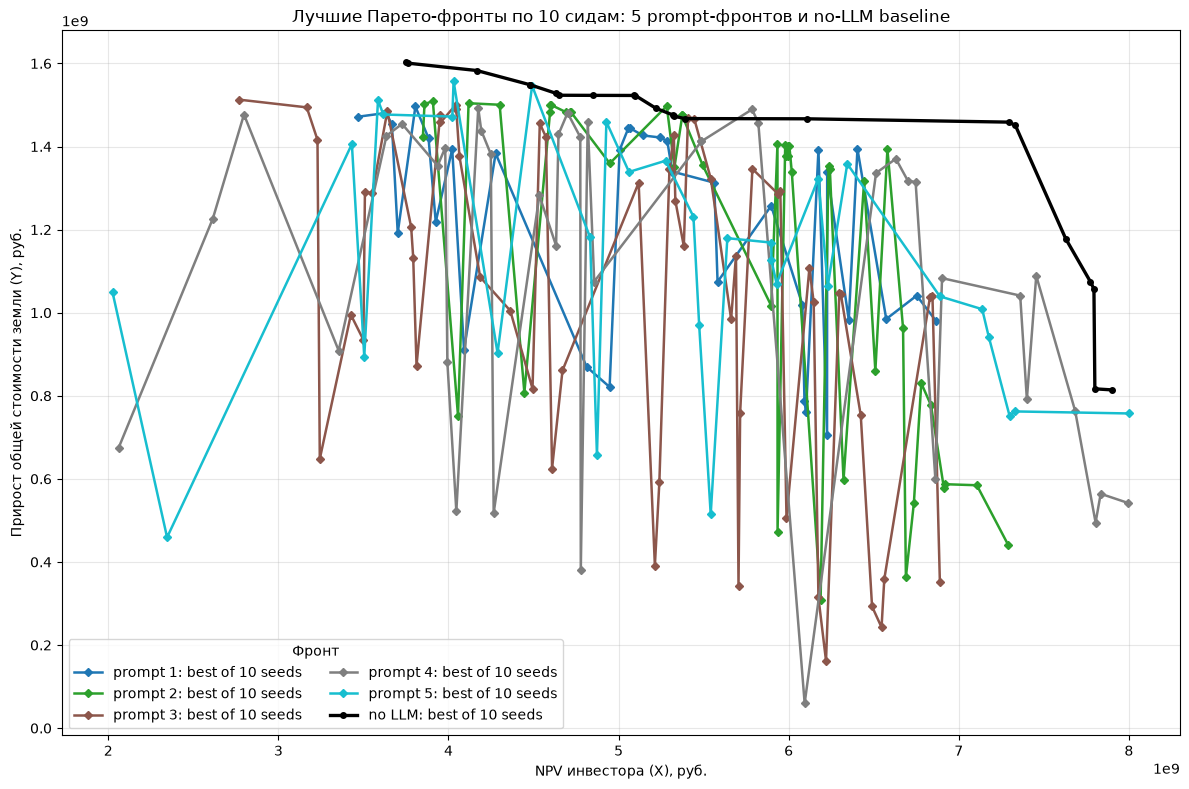

Сохранено в best_pareto_fronts_10_seeds


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEEDS = range(32, 42)  # 10 сидов: 32..41
PROMPT_IDS = range(1, 6)
notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
llm_root = notebook_dir / "nsga_2_llm_prompts"
no_llm_root = notebook_dir / "nsga_2_without_llm"
out_root = notebook_dir / "best_pareto_fronts_10_seeds"
out_root.mkdir(exist_ok=True)


def read_jsonl(path, **extra_cols):
    df = pd.read_json(path, lines=True)
    for name, value in extra_cols.items():
        df[name] = value
    if "scenario_id" not in df.columns:
        df.insert(0, "scenario_id", [f"{path.stem}_{i + 1}" for i in range(len(df))])
    return df


def numeric(df, cols):
    out = df.copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out.dropna(subset=cols).reset_index(drop=True)


def nondominated(df, cols):
    df = numeric(df, cols)
    values = df[cols].to_numpy(float)
    keep = np.ones(len(values), dtype=bool)
    for i, point in enumerate(values):
        others = np.delete(values, i, axis=0)
        keep[i] = not np.any(np.all(others >= point, axis=1) & np.any(others > point, axis=1))
    return df.loc[keep].sort_values(cols[:2]).reset_index(drop=True)
prompt_best_fronts = {}
prompt_input_counts = {}
for prompt_id in PROMPT_IDS:
    parts = []
    missing = []
    for seed in SEEDS:
        path = llm_root / f"seed_{seed}" / f"prompt_{prompt_id}" / f"prompt_{prompt_id}_pareto_front.jsonl"
        if path.exists():
            parts.append(read_jsonl(path, seed=seed, prompt_id=prompt_id))
        else:
            missing.append(path)
    if missing:
        raise FileNotFoundError(f"Нет файлов для prompt {prompt_id}: {missing[:3]}")

    combined = pd.concat(parts, ignore_index=True)
    prompt_input_counts[prompt_id] = len(combined)
    front = nondominated(combined, ["investor_npv", "land_value_gain", "llm score"])
    prompt_best_fronts[prompt_id] = front
    prompt_out_dir = out_root / f"prompt_{prompt_id}"
    prompt_out_dir.mkdir(exist_ok=True)
    front.to_json(prompt_out_dir / f"prompt_{prompt_id}_best_pareto_front_10_seeds.jsonl", orient="records", lines=True, force_ascii=False)

no_llm_parts = []
missing = []
for seed in SEEDS:
    path = no_llm_root / f"seed_{seed}" / f"no_llm_pareto_front_{seed}.jsonl"
    if path.exists():
        no_llm_parts.append(read_jsonl(path, seed=seed))
    else:
        missing.append(path)
if missing:
    raise FileNotFoundError(f"Нет no-LLM файлов: {missing[:3]}")

no_llm_combined = pd.concat(no_llm_parts, ignore_index=True)
no_llm_best_front = nondominated(no_llm_combined, ["investor_npv", "land_value_gain"])
no_llm_best_front.to_json(out_root / "no_llm_best_pareto_front_10_seeds.jsonl", orient="records", lines=True, force_ascii=False)

summary = pd.DataFrame(
    [
        {
            "front": f"prompt {prompt_id}",
            "input_solutions": prompt_input_counts[prompt_id],
            "best_front_solutions": len(front),
            "seeds_on_front": ", ".join(map(str, sorted(front["seed"].unique()))),
        }
        for prompt_id, front in prompt_best_fronts.items()
    ]
    + [
        {
            "front": "no LLM",
            "input_solutions": len(no_llm_combined),
            "best_front_solutions": len(no_llm_best_front),
            "seeds_on_front": ", ".join(map(str, sorted(no_llm_best_front["seed"].unique()))),
        }
    ]
)
display(summary)

plt.figure(figsize=(12, 8))
cmap = plt.get_cmap("tab10", len(prompt_best_fronts))
for i, (prompt_id, front) in enumerate(prompt_best_fronts.items()):
    plot_front = front.sort_values("investor_npv")
    plt.plot(
        plot_front["investor_npv"],
        plot_front["land_value_gain"],
        marker="D",
        ms=4,
        lw=1.8,
        color=cmap(i),
        label=f"prompt {prompt_id}: best of 10 seeds",
    )

plot_no_llm = no_llm_best_front.sort_values("investor_npv")
plt.plot(
    plot_no_llm["investor_npv"],
    plot_no_llm["land_value_gain"],
    marker="o",
    ms=4,
    lw=2.4,
    color="black",
    label="no LLM: best of 10 seeds",
)
plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Лучшие Парето-фронты по 10 сидам: 5 prompt-фронтов и no-LLM baseline")
plt.grid(True, alpha=0.3)
plt.legend(title="Фронт", ncol=2)
plt.tight_layout()
plt.show()

print(f"Сохранено в {out_root}")

SEED = "best_10_seeds"
selected_front = no_llm_best_front
prompt_fronts = prompt_best_fronts


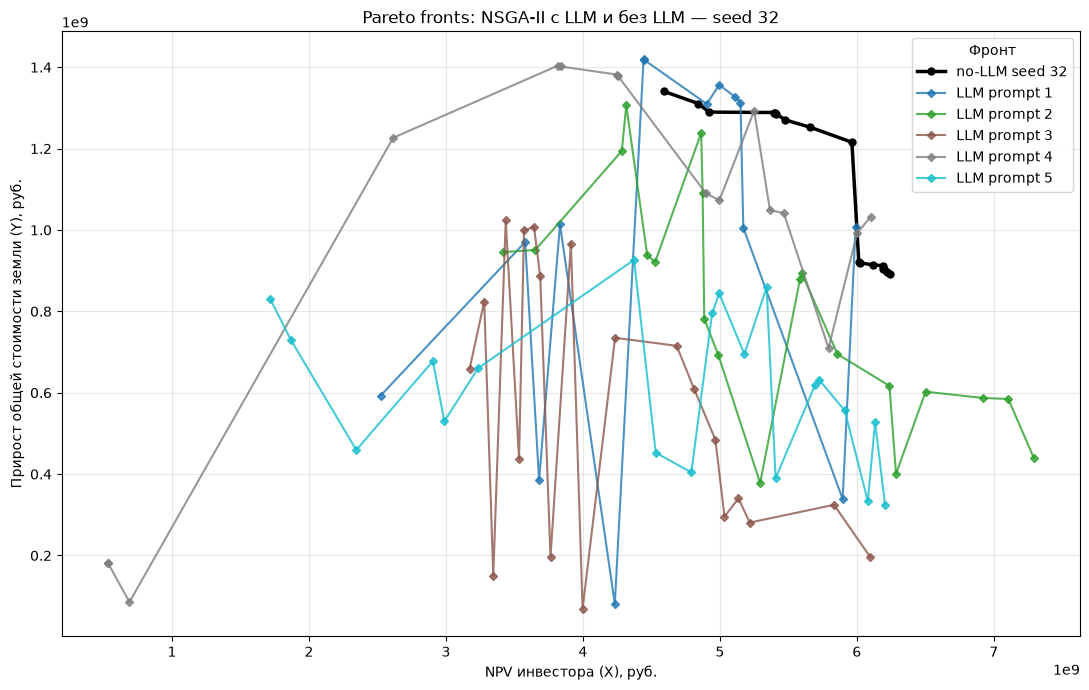

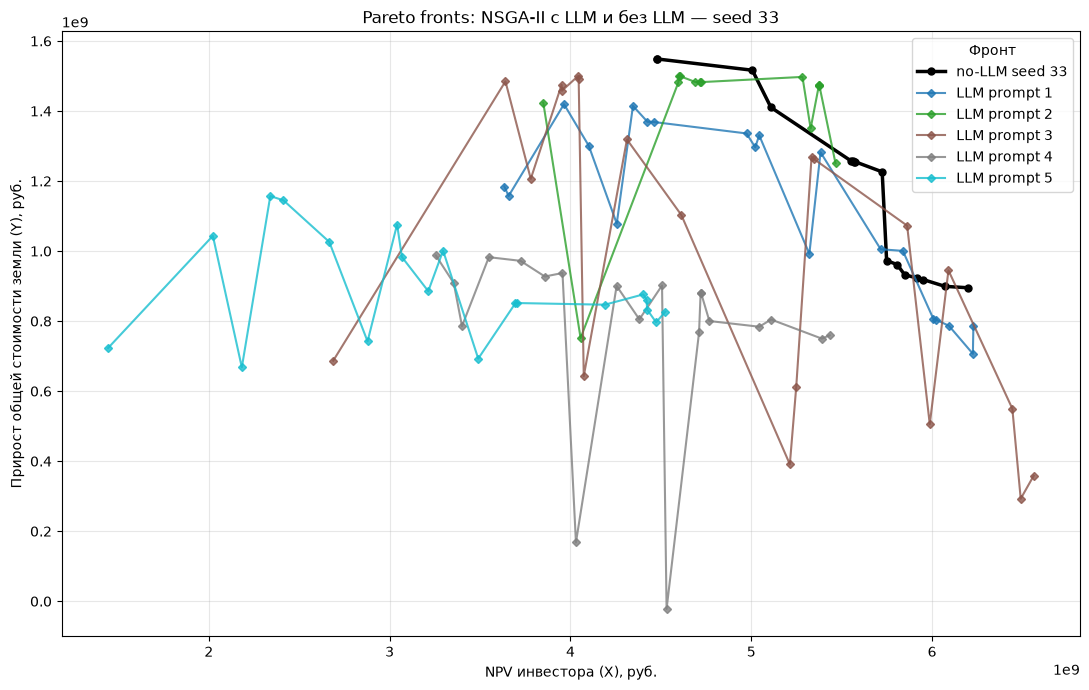

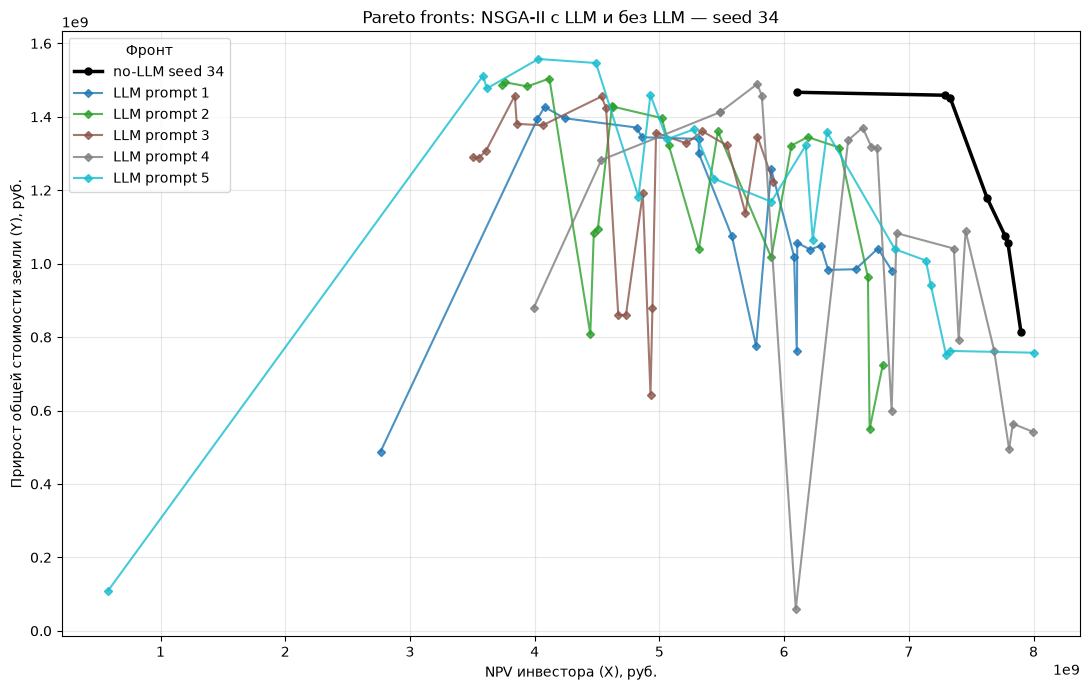

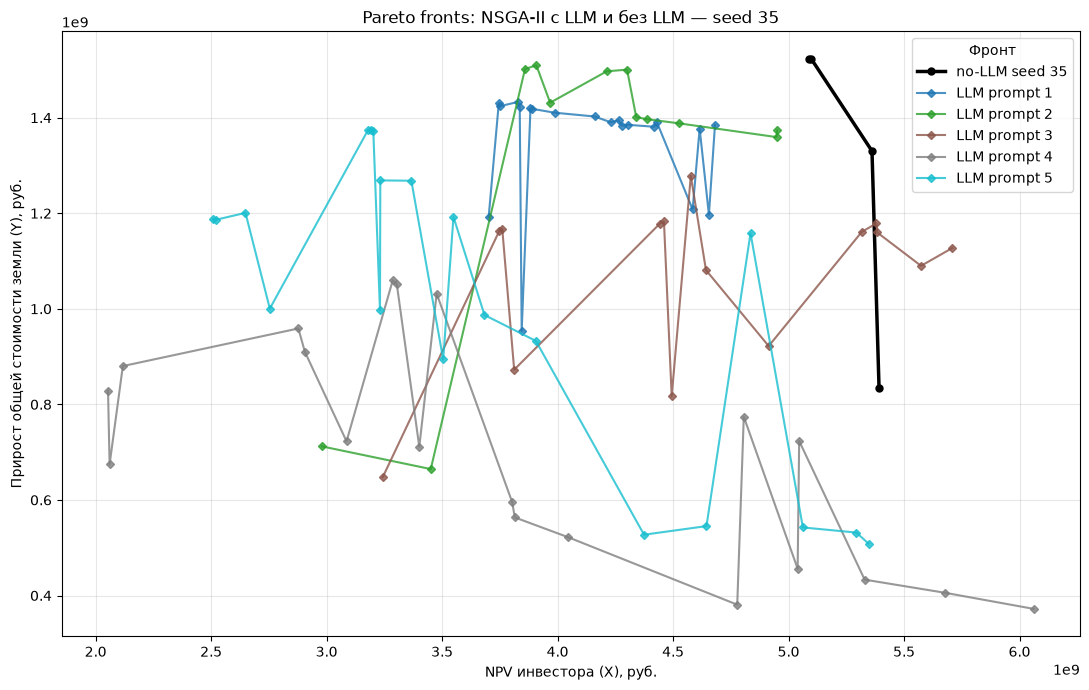

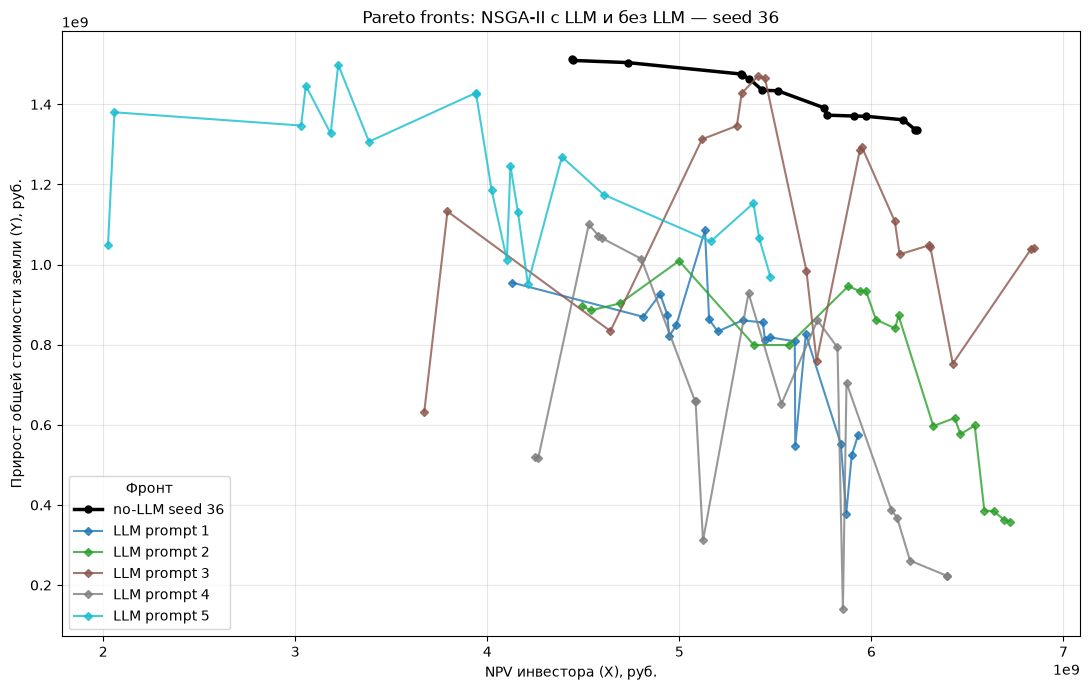

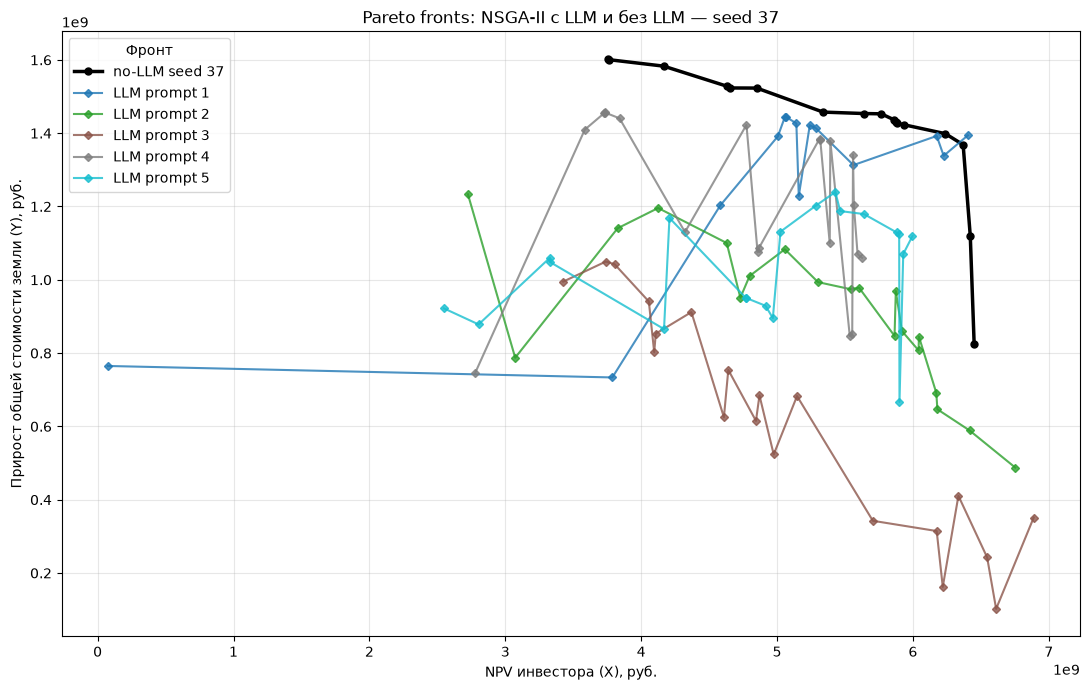

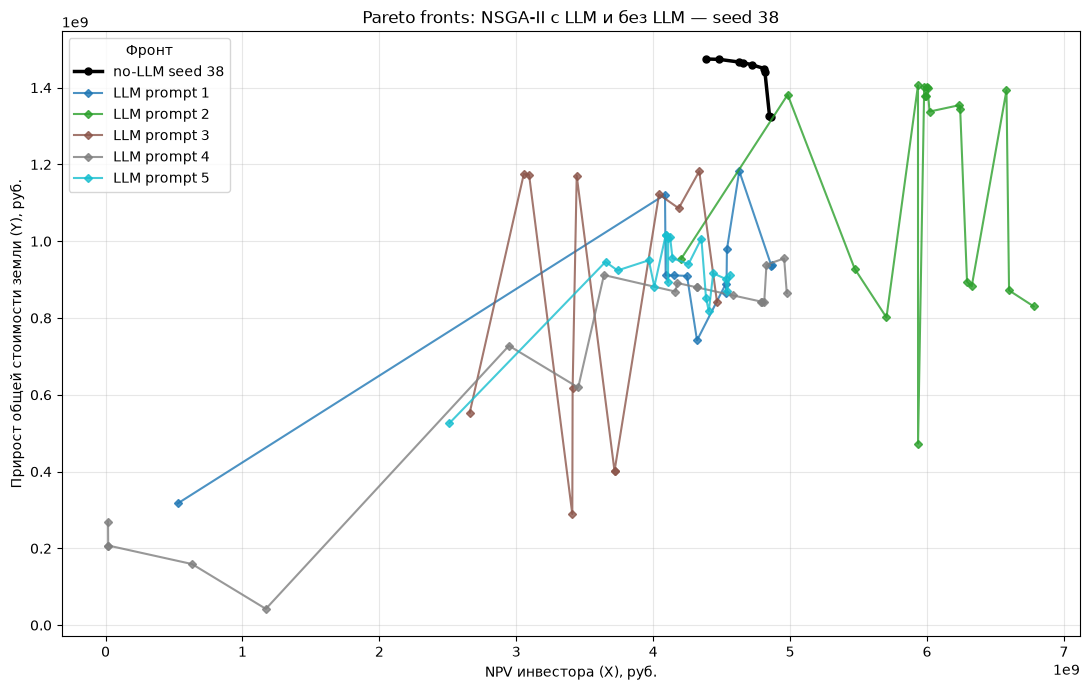

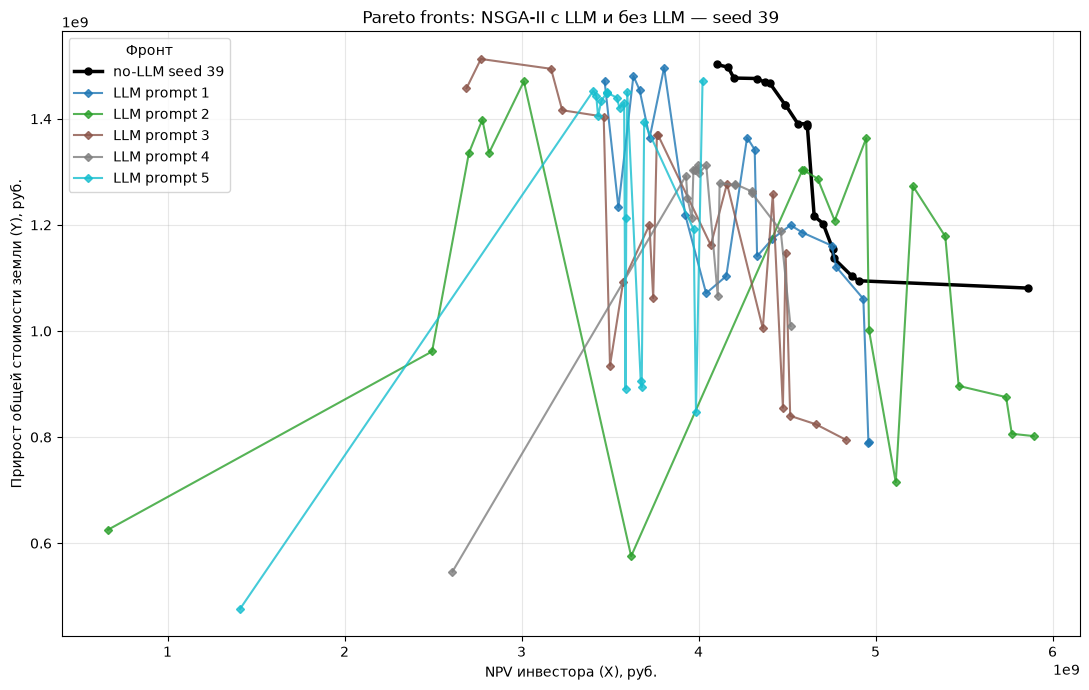

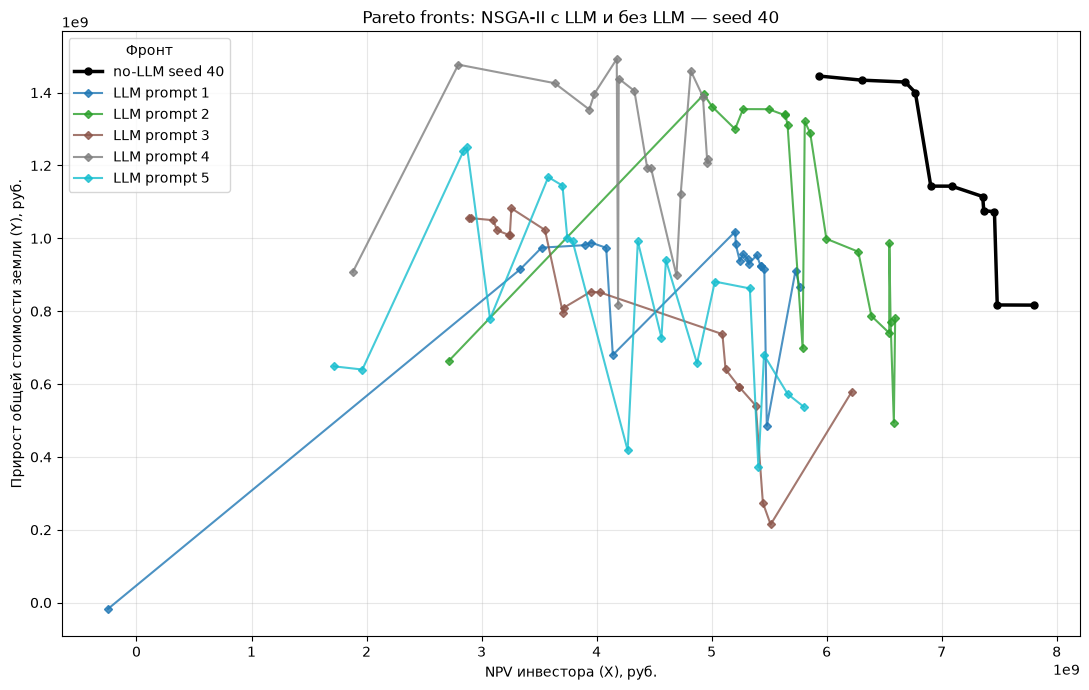

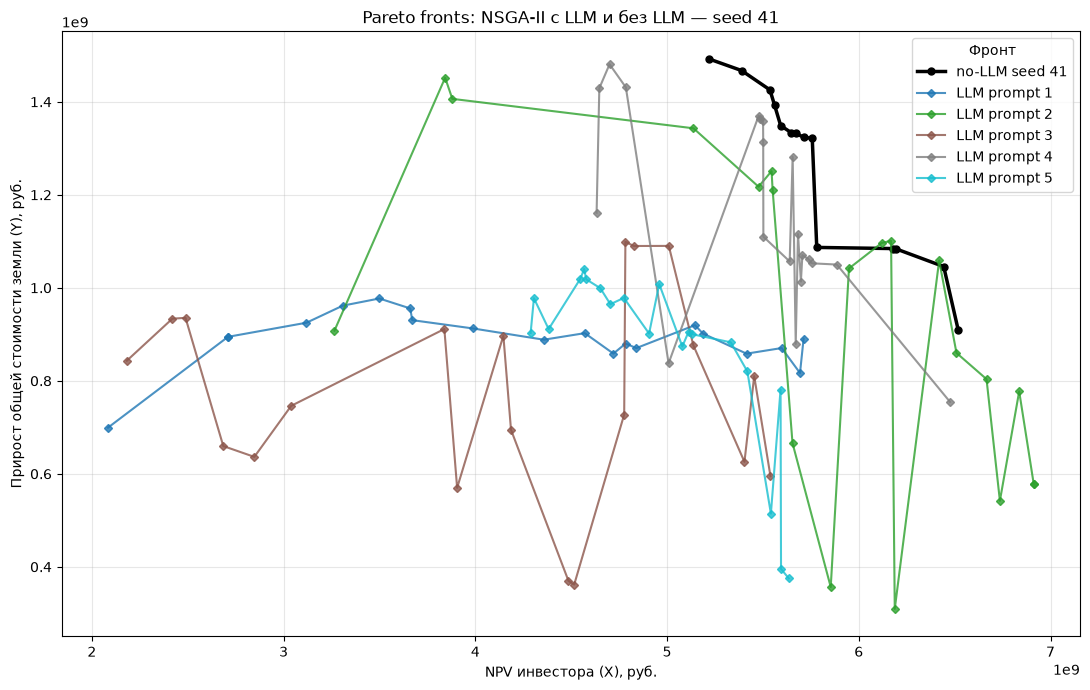

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
no_llm_root = notebook_dir / "nsga_2_without_llm"
llm_root = notebook_dir / "nsga_2_llm_prompts"
seeds = range(32, 42)
prompt_ids = range(1, 6)
prompt_colors = plt.get_cmap("tab10", len(prompt_ids))

for seed in seeds:
    plt.figure(figsize=(11, 7))

    no_llm_path = no_llm_root / f"seed_{seed}" / f"no_llm_pareto_front_{seed}.jsonl"
    no_llm_df = pd.read_json(no_llm_path, lines=True).sort_values("investor_npv")
    plt.plot(
        no_llm_df["investor_npv"],
        no_llm_df["land_value_gain"],
        marker="o",
        ms=5,
        lw=2.5,
        color="black",
        label=f"no-LLM seed {seed}",
    )

    for color_index, prompt_id in enumerate(prompt_ids):
        llm_path = (
            llm_root / f"seed_{seed}" / f"prompt_{prompt_id}"
            / f"prompt_{prompt_id}_pareto_front.jsonl"
        )
        llm_df = pd.read_json(llm_path, lines=True).sort_values("investor_npv")
        plt.plot(
            llm_df["investor_npv"],
            llm_df["land_value_gain"],
            marker="D",
            ms=4,
            lw=1.5,
            alpha=0.8,
            color=prompt_colors(color_index),
            label=f"LLM prompt {prompt_id}",
        )

    plt.xlabel("NPV инвестора (X), руб.")
    plt.ylabel("Прирост общей стоимости земли (Y), руб.")
    plt.title(f"Pareto fronts: NSGA-II с LLM и без LLM — seed {seed}")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Фронт")
    plt.tight_layout()
    plt.show()


# LLM score для выбранного seed


In [3]:
prompts = {
    1: """
Evaluate the presented scenario based on the criterion of social inclusiveness and low displacement risk.
Determine whether the scenario preserves the social and functional diversity of the area, access to everyday services, and opportunities for vulnerable user groups.
Assign a score from 0 to 1.
""".strip(),
    2: """
Evaluate the presented scenario based on the criterion of strategic relevance for the long-term development of the city and district.
Consider compactness, functional mix, the balance of housing, jobs, and services, and the area's ability to adapt to future changes.
Assign a score from 0 to 1.
""".strip(),
    3: """
Evaluate the presented scenario based on its ability to create conditions for active urban life.
Consider functional mix, the potential for active ground floors, pedestrian accessibility, public spaces, and diverse everyday use scenarios throughout the day and evening.
Assign a score from 0 to 1.
""".strip(),
    4: """
Evaluate the presented scenario based on the criterion of aligning the interests of various land users and minimizing conflict risk.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
""".strip(),
    5: """
Evaluate the presented scenario based on the criterion of environmental and infrastructure sustainability.
Consider building density, transport and infrastructure load, resource efficiency, environmental consequences, and the possibility of phased adaptation of the area.
Assign a score from 0 to 1.
""".strip(),
}


In [4]:
from urbanomy.methods.agent import SingleAgentBaseline, init_llm
from urbanomy.methods.land_value_modeling import Evaluation, StrategicAlignmentScorer

json_rule = '\nReturn only valid JSON, no markdown: {"score": 0.0}'
scored_selected_seed = {}
baseline = None

for prompt_id, prompt in prompts.items():
    prompt_out_dir = out_root / f"prompt_{prompt_id}"
    prompt_out_dir.mkdir(exist_ok=True)
    out_path = prompt_out_dir / f"no_llm_scored_by_prompt_{prompt_id}_best_10_seeds.jsonl"

    df = read_jsonl(out_path) if out_path.exists() else selected_front.copy()
    if "prompt_id" not in df.columns:
        df.insert(0, "prompt_id", prompt_id)
    if "llm score" not in df.columns:
        df["llm score"] = pd.NA
    df["llm score"] = pd.to_numeric(df["llm score"], errors="coerce")

    missing = df["llm score"].isna()
    if not missing.any():
        scored_selected_seed[prompt_id] = df
        continue

    if baseline is None:
        llm = init_llm("deepseek/deepseek-v4-flash")
        baseline = SingleAgentBaseline(llm=llm, output_schema=Evaluation)
    scorer = StrategicAlignmentScorer(baseline=baseline, prompt=prompt + json_rule)
    for idx, row in df.loc[missing].iterrows():
        scored = scorer.score_candidate(
            params_repaired=row["params_repaired"],
            land_value_gain=row["land_value_gain"],
            investor_npv=row["investor_npv"],
        )
        df.at[idx, "prompt_id"] = prompt_id
        df.at[idx, "llm score"] = scored["score"]
        df.to_json(out_path, orient="records", lines=True, force_ascii=False)

    df["llm score"] = pd.to_numeric(df["llm score"], errors="coerce")
    df.to_json(out_path, orient="records", lines=True, force_ascii=False)
    scored_selected_seed[prompt_id] = df

score_summary = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "n": len(df),
        "mean_llm_score": df["llm score"].mean(),
        "median_llm_score": df["llm score"].median(),
        "min_llm_score": df["llm score"].min(),
        "max_llm_score": df["llm score"].max(),
        "path": str(out_root / f"prompt_{prompt_id}" / f"no_llm_scored_by_prompt_{prompt_id}_best_10_seeds.jsonl"),
    }
    for prompt_id, df in scored_selected_seed.items()
])
display(score_summary)


/Users/mvin/Code/paper_1/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


,prompt_id,n,mean_llm_score,median_llm_score,min_llm_score,max_llm_score,path
0,1,22,0.144091,0.175,0.00,0.40,best_pareto_fronts_10_seeds/prompt_1/no_llm_sc...
1,2,22,0.338636,0.350,0.20,0.50,best_pareto_fronts_10_seeds/prompt_2/no_llm_sc...
2,3,22,0.272727,0.250,0.12,0.45,best_pareto_fronts_10_seeds/prompt_3/no_llm_sc...
3,4,22,0.306818,0.300,0.20,0.45,best_pareto_fronts_10_seeds/prompt_4/no_llm_sc...
4,5,22,0.302273,0.320,0.12,0.46,best_pareto_fronts_10_seeds/prompt_5/no_llm_sc...


## LLM score для каждого no-LLM Парето-фронта по сидам

Для каждой пары `prompt × seed` код оценивает все решения из `no_llm_pareto_front_{seed}.jsonl` тем же LLM-критерием. В `nsga_2_without_llm` создаётся папка каждого seed с копией исходного фронта и пятью подпапками промптов. Результаты сохраняются после каждой успешно оценённой точки, поэтому прерванный расчёт можно продолжить без повторной оценки готовых решений.


In [5]:
scored_no_llm_seed_fronts = {}

for prompt_id, prompt in prompts.items():
    scorer = None

    for seed in SEEDS:
        seed_dir = no_llm_root / f"seed_{seed}"
        seed_dir.mkdir(exist_ok=True)
        source_path = seed_dir / f"no_llm_pareto_front_{seed}.jsonl"
        source_df = read_jsonl(source_path)

        prompt_out_dir = seed_dir / f"prompt_{prompt_id}"
        prompt_out_dir.mkdir(exist_ok=True)
        out_path = prompt_out_dir / f"no_llm_pareto_front_{seed}_scored_by_prompt_{prompt_id}.jsonl"
        df = read_jsonl(out_path) if out_path.exists() else source_df.copy()

        if len(df) != len(source_df):
            raise ValueError(
                f"Число строк изменилось для prompt={prompt_id}, seed={seed}: "
                f"source={len(source_df)}, saved={len(df)}"
            )
        if "seed" not in df.columns:
            df.insert(0, "seed", seed)
        if "prompt_id" not in df.columns:
            df.insert(1, "prompt_id", prompt_id)
        if "llm score" not in df.columns:
            df["llm score"] = pd.NA
        df["seed"] = seed
        df["prompt_id"] = prompt_id
        df["llm score"] = pd.to_numeric(df["llm score"], errors="coerce")
        missing_indices = df.index[df["llm score"].isna()].tolist()

        print(
            f"[prompt {prompt_id}/{len(prompts)} | seed {seed} | "
            f"готово {len(df) - len(missing_indices)}/{len(df)}] {source_path.name}"
        )
        if not missing_indices:
            print(f"  ✓ уже посчитано: {out_path}")
            scored_no_llm_seed_fronts[prompt_id, seed] = df
            continue

        if baseline is None:
            llm = init_llm("deepseek/deepseek-v4-flash")
            baseline = SingleAgentBaseline(llm=llm, output_schema=Evaluation)
        if scorer is None:
            scorer = StrategicAlignmentScorer(baseline=baseline, prompt=prompt + json_rule)

        df.to_json(out_path, orient="records", lines=True, force_ascii=False)
        for position, idx in enumerate(missing_indices, start=1):
            row = df.loc[idx]
            scenario_id = row.get("scenario_id", idx)
            print(
                f"  → prompt={prompt_id}, seed={seed}, "
                f"solution={position}/{len(missing_indices)}, scenario_id={scenario_id}"
            )
            try:
                scored = scorer.score_candidate(
                    params_repaired=row["params_repaired"],
                    land_value_gain=row["land_value_gain"],
                    investor_npv=row["investor_npv"],
                )
                df.at[idx, "llm score"] = scored["score"]
                df.to_json(out_path, orient="records", lines=True, force_ascii=False)
                print(f"    ✓ llm score={float(scored['score']):.4f}")
            except Exception as error:
                print(f"    ✗ ошибка: {type(error).__name__}: {error}")
                raise

        scored_no_llm_seed_fronts[prompt_id, seed] = df
        print(f"  ✓ сохранено: {out_path}")

seed_score_summary = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "seed": seed,
        "n": len(df),
        "mean_llm_score": df["llm score"].mean(),
        "median_llm_score": df["llm score"].median(),
        "min_llm_score": df["llm score"].min(),
        "max_llm_score": df["llm score"].max(),
        "path": str(no_llm_root / f"seed_{seed}" / f"prompt_{prompt_id}" / f"no_llm_pareto_front_{seed}_scored_by_prompt_{prompt_id}.jsonl"),
    }
    for (prompt_id, seed), df in sorted(scored_no_llm_seed_fronts.items())
])
display(seed_score_summary)


[prompt 1/5 | seed 32 | готово 17/17] no_llm_pareto_front_32.jsonl
  ✓ уже посчитано: nsga_2_without_llm/seed_32/prompt_1/no_llm_pareto_front_32_scored_by_prompt_1.jsonl
[prompt 1/5 | seed 33 | готово 16/16] no_llm_pareto_front_33.jsonl
  ✓ уже посчитано: nsga_2_without_llm/seed_33/prompt_1/no_llm_pareto_front_33_scored_by_prompt_1.jsonl
[prompt 1/5 | seed 34 | готово 7/7] no_llm_pareto_front_34.jsonl
  ✓ уже посчитано: nsga_2_without_llm/seed_34/prompt_1/no_llm_pareto_front_34_scored_by_prompt_1.jsonl
[prompt 1/5 | seed 35 | готово 4/4] no_llm_pareto_front_35.jsonl
  ✓ уже посчитано: nsga_2_without_llm/seed_35/prompt_1/no_llm_pareto_front_35_scored_by_prompt_1.jsonl
[prompt 1/5 | seed 36 | готово 15/15] no_llm_pareto_front_36.jsonl
  ✓ уже посчитано: nsga_2_without_llm/seed_36/prompt_1/no_llm_pareto_front_36_scored_by_prompt_1.jsonl
[prompt 1/5 | seed 37 | готово 17/17] no_llm_pareto_front_37.jsonl
  ✓ уже посчитано: nsga_2_without_llm/seed_37/prompt_1/no_llm_pareto_front_37_scored_by

,prompt_id,seed,n,mean_llm_score,median_llm_score,min_llm_score,max_llm_score,path
0,1,32,17,0.165294,0.200,0.00,0.5100,nsga_2_without_llm/seed_32/prompt_1/no_llm_par...
1,1,33,16,0.157500,0.200,0.00,0.3000,nsga_2_without_llm/seed_33/prompt_1/no_llm_par...
2,1,34,7,0.171429,0.200,0.00,0.2000,nsga_2_without_llm/seed_34/prompt_1/no_llm_par...
3,1,35,4,0.162500,0.175,0.10,0.2000,nsga_2_without_llm/seed_35/prompt_1/no_llm_par...
4,1,36,15,0.303333,0.300,0.00,0.7000,nsga_2_without_llm/seed_36/prompt_1/no_llm_par...
5,1,37,17,0.241176,0.200,0.00,0.4000,nsga_2_without_llm/seed_37/prompt_1/no_llm_par...
6,1,38,9,0.311111,0.300,0.15,0.7000,nsga_2_without_llm/seed_38/prompt_1/no_llm_par...
7,1,39,18,0.197222,0.200,0.10,0.3000,nsga_2_without_llm/seed_39/prompt_1/no_llm_par...
8,1,40,11,0.177273,0.200,0.00,0.4000,nsga_2_without_llm/seed_40/prompt_1/no_llm_par...
9,1,41,14,0.237857,0.200,0.00,0.7000,nsga_2_without_llm/seed_41/prompt_1/no_llm_par...


# Convergence

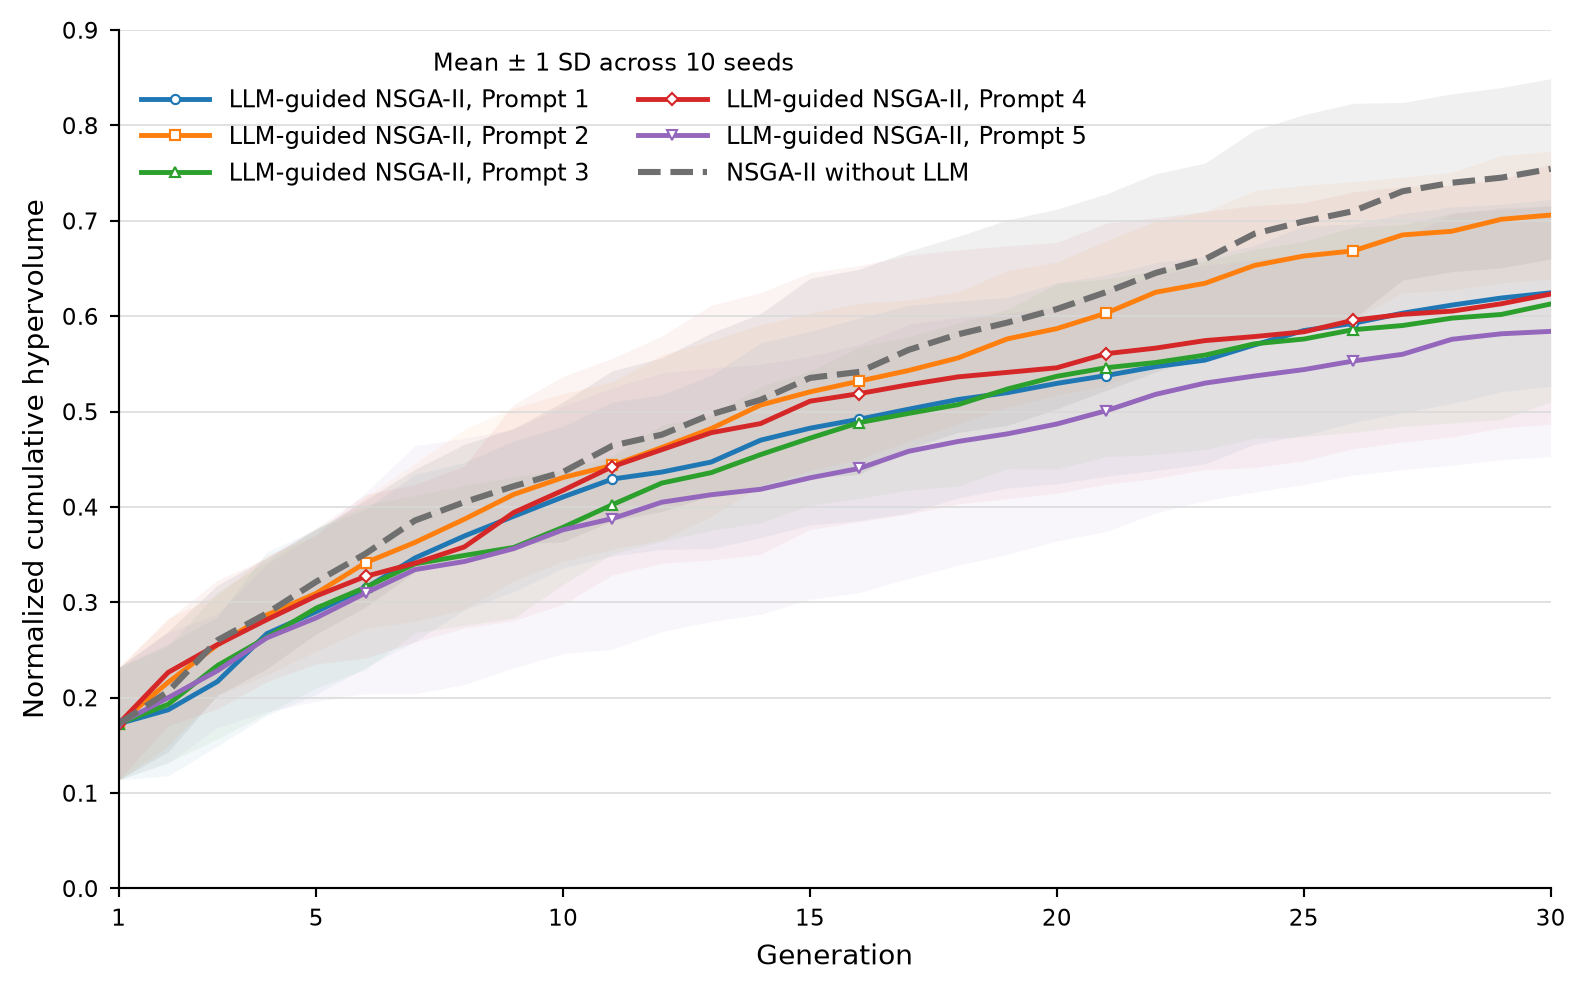

In [6]:
CONVERGENCE_POP_SIZE = 20
CONVERGENCE_N_GENERATIONS = 30
CONVERGENCE_OBJECTIVES = ["investor_npv", "land_value_gain"]

llm_log_paths = {
    (prompt_id, seed): (
        llm_root / f"seed_{seed}" / f"prompt_{prompt_id}"
        / f"prompt_{prompt_id}_optimization_log.jsonl"
    )
    for prompt_id in PROMPT_IDS
    for seed in SEEDS
}
no_llm_log_paths = {
    seed: no_llm_root / f"seed_{seed}" / f"no_llm_optimization_log_{seed}.jsonl"
    for seed in SEEDS
}
all_log_paths = list(no_llm_log_paths.values()) + list(llm_log_paths.values())
missing = [path for path in all_log_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f"Optimization logs not found: {missing[:3]}")

log_values = {}
expected_evaluations = CONVERGENCE_POP_SIZE * CONVERGENCE_N_GENERATIONS
for path in all_log_paths:
    df = pd.read_json(path, lines=True).sort_values("eval_id")
    values = df[CONVERGENCE_OBJECTIVES].apply(pd.to_numeric, errors="coerce")
    if len(values) != expected_evaluations or values.isna().any().any():
        raise ValueError(
            f"Expected {expected_evaluations} numeric evaluations in {path}, got {len(values)}"
        )
    log_values[path] = values.to_numpy(float)

# A shared scale makes all prompts and both algorithms directly comparable.
all_values = np.vstack(list(log_values.values()))
span = np.ptp(all_values, axis=0)
convergence_reference = all_values.min(axis=0) - np.maximum(0.01 * span, 1.0)
convergence_norm = np.prod(all_values.max(axis=0) - convergence_reference)


def hypervolume_2d_max(points, reference):
    """Area dominated by maximization points relative to the reference point."""
    points = np.asarray(points, dtype=float)
    points = points[np.all(points >= reference, axis=1)]
    ordered = points[np.argsort(points[:, 0])[::-1]]
    hv, best_y = 0.0, reference[1]
    for index, (x, y) in enumerate(ordered):
        best_y = max(best_y, y)
        next_x = ordered[index + 1, 0] if index + 1 < len(ordered) else reference[0]
        hv += max(0.0, x - next_x) * max(0.0, best_y - reference[1])
    return hv


assert np.isclose(hypervolume_2d_max([[1, 0], [0, 1]], [-1, -1]), 3.0)


def running_hypervolume(points):
    return np.array([
        hypervolume_2d_max(points[: generation * CONVERGENCE_POP_SIZE], convergence_reference)
        / convergence_norm
        for generation in range(1, CONVERGENCE_N_GENERATIONS + 1)
    ])


curves = {path: running_hypervolume(values) for path, values in log_values.items()}
convergence = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "seed": seed,
        "algorithm": algorithm,
        "generation": generation,
        "hypervolume_norm": hv,
    }
    for prompt_id in PROMPT_IDS
    for seed in SEEDS
    for algorithm, path in (
        ("LLM-guided NSGA-II", llm_log_paths[prompt_id, seed]),
        ("NSGA-II without LLM", no_llm_log_paths[seed]),
    )
    for generation, hv in enumerate(curves[path], start=1)
])
convergence_summary = (
    convergence.groupby(["prompt_id", "algorithm", "generation"])["hypervolume_norm"]
    .agg(mean="mean", std="std")
    .reset_index()
)

prompt_colors = {
    1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728", 5: "#9467bd"
}
prompt_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}
baseline_color = "#6f6f6f"
publication_style = {
    "figure.dpi": 220,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}

with plt.rc_context(publication_style):
    fig, ax = plt.subplots(figsize=(7.1, 4.4), constrained_layout=True)

    for prompt_id in PROMPT_IDS:
        stats = convergence_summary.query(
            "prompt_id == @prompt_id and algorithm == 'LLM-guided NSGA-II'"
        )
        generation = stats["generation"].to_numpy()
        mean = stats["mean"].to_numpy()
        std = stats["std"].to_numpy()
        color = prompt_colors[prompt_id]
        ax.plot(
            generation, mean, color=color, lw=1.6, marker=prompt_markers[prompt_id],
            markevery=5, ms=3, markerfacecolor="white", markeredgewidth=0.7,
            label=f"LLM-guided NSGA-II, Prompt {prompt_id}",
        )
        ax.fill_between(
            generation, np.clip(mean - std, 0, None), mean + std,
            color=color, alpha=0.055, linewidth=0,
        )

    baseline_prompt_id = min(PROMPT_IDS)
    baseline = convergence_summary.query(
        "prompt_id == @baseline_prompt_id and algorithm == 'NSGA-II without LLM'"
    )
    generation = baseline["generation"].to_numpy()
    mean = baseline["mean"].to_numpy()
    std = baseline["std"].to_numpy()
    ax.plot(
        generation, mean, color=baseline_color, lw=2.0, linestyle="--",
        label="NSGA-II without LLM",
    )
    ax.fill_between(
        generation, np.clip(mean - std, 0, None), mean + std,
        color=baseline_color, alpha=0.10, linewidth=0,
    )

    ax.set(xlabel="Generation", ylabel="Normalized cumulative hypervolume",
           xlim=(1, CONVERGENCE_N_GENERATIONS), ylim=(0, 0.9))
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.7)
    ax.legend(
        loc="upper left", ncol=2, frameon=False, handlelength=2.8,
        title="Mean ± 1 SD across 10 seeds",
    )
    plt.show()



## Three-objective convergence (including LLM score)

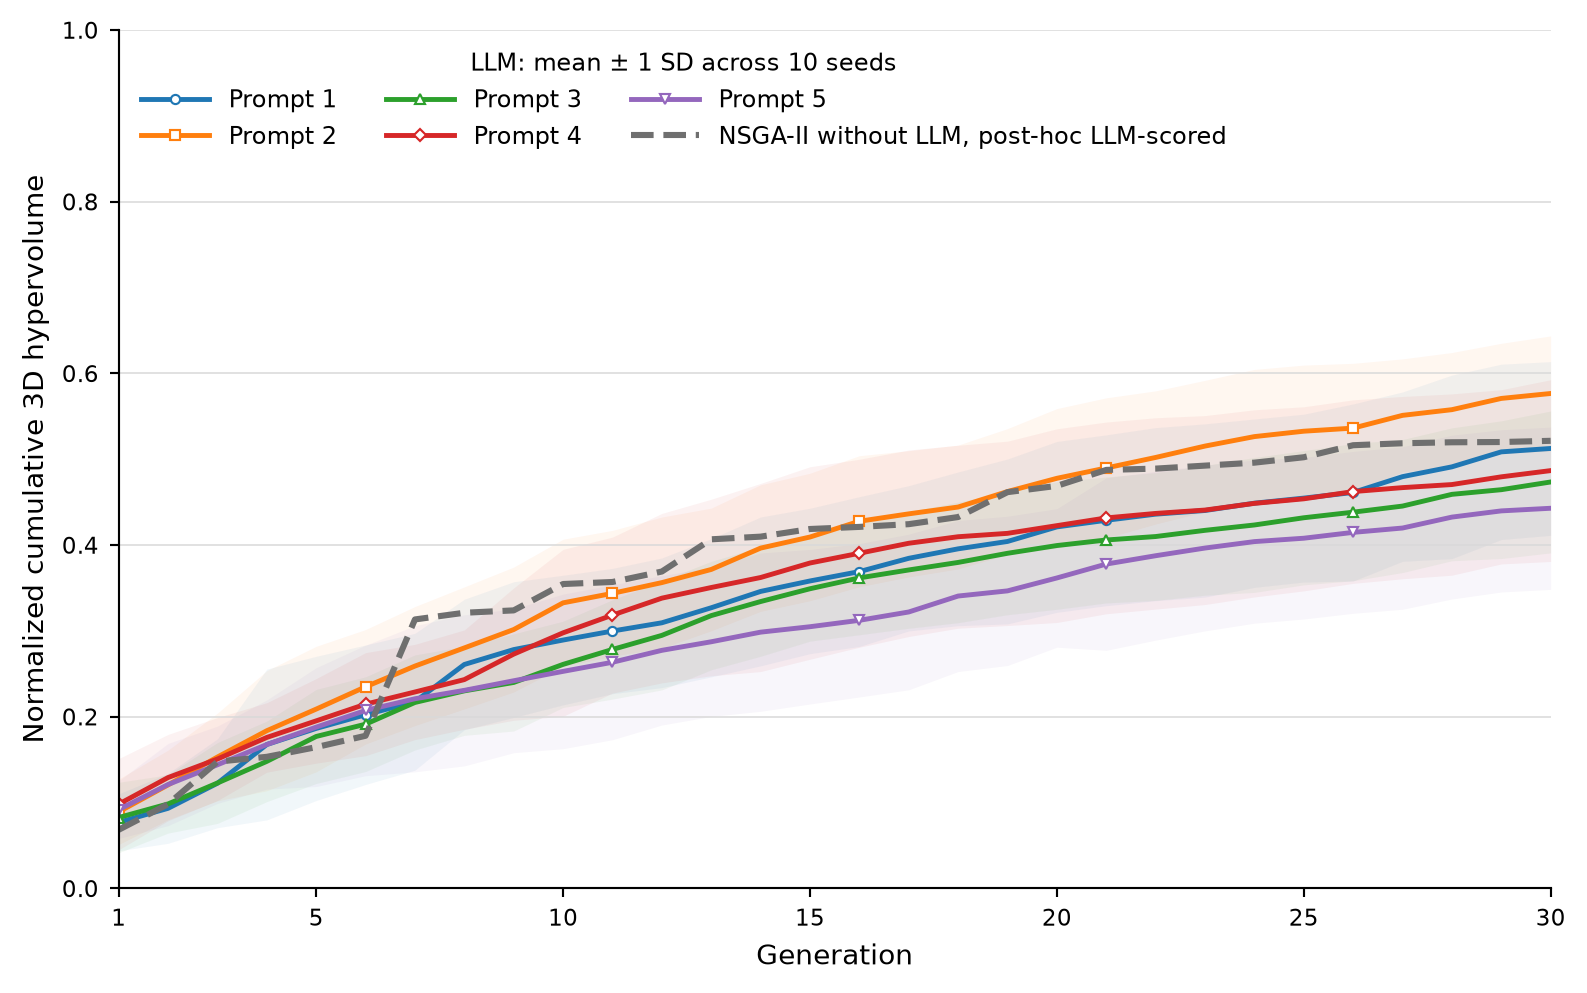

In [7]:
from pymoo.indicators.hv import HV

CONVERGENCE_3D_OBJECTIVES = ["investor_npv", "land_value_gain", "llm score"]
llm_log_values_3d = {}
for (prompt_id, seed), path in llm_log_paths.items():
    df = pd.read_json(path, lines=True).sort_values("eval_id")
    values = df[CONVERGENCE_3D_OBJECTIVES].apply(pd.to_numeric, errors="coerce")
    if len(values) != expected_evaluations or values.isna().any().any():
        raise ValueError(
            f"Expected {expected_evaluations} numeric 3D evaluations in {path}, got {len(values)}"
        )
    llm_log_values_3d[prompt_id, seed] = values.to_numpy(float)

NO_LLM_3D_SEED = 32
NO_LLM_3D_PROMPT = 1
no_llm_3d_path = (
    no_llm_root / f"seed_{NO_LLM_3D_SEED}" / f"prompt_{NO_LLM_3D_PROMPT}"
    / f"no_llm_optimization_log_{NO_LLM_3D_SEED}_scored_by_prompt_{NO_LLM_3D_PROMPT}.jsonl"
)
no_llm_3d_df = pd.read_json(no_llm_3d_path, lines=True).sort_values("eval_id")
no_llm_values_3d = no_llm_3d_df[CONVERGENCE_3D_OBJECTIVES].apply(
    pd.to_numeric, errors="coerce"
).to_numpy(float)
if len(no_llm_values_3d) != expected_evaluations or np.isnan(no_llm_values_3d).any():
    raise ValueError(f"Incomplete scored no-LLM log: {no_llm_3d_path}")

# Shared reference and normalization make all prompt curves directly comparable.
all_values_3d = np.vstack(list(llm_log_values_3d.values()) + [no_llm_values_3d])
span_3d = np.ptp(all_values_3d, axis=0)
reference_3d = all_values_3d.min(axis=0) - np.maximum(0.01 * span_3d, [1.0, 1.0, 0.01])
scale_3d = all_values_3d.max(axis=0) - reference_3d
hv_3d_indicator = HV(ref_point=np.ones(3))


def running_hypervolume_3d(points):
    minimization_points = 1.0 - (points - reference_3d) / scale_3d
    return np.array([
        hv_3d_indicator(minimization_points[: generation * CONVERGENCE_POP_SIZE])
        for generation in range(1, CONVERGENCE_N_GENERATIONS + 1)
    ])


curves_3d = {key: running_hypervolume_3d(values) for key, values in llm_log_values_3d.items()}
assert all(np.all(np.diff(curve) >= -1e-12) for curve in curves_3d.values())
no_llm_curve_3d = running_hypervolume_3d(no_llm_values_3d)
assert np.all(np.diff(no_llm_curve_3d) >= -1e-12)

convergence_3d = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "seed": seed,
        "generation": generation,
        "hypervolume_norm": hv,
    }
    for (prompt_id, seed), curve in curves_3d.items()
    for generation, hv in enumerate(curve, start=1)
])
convergence_3d_summary = (
    convergence_3d.groupby(["prompt_id", "generation"])["hypervolume_norm"]
    .agg(mean="mean", std="std")
    .reset_index()
)

with plt.rc_context(publication_style):
    fig_3d, ax_3d = plt.subplots(figsize=(7.1, 4.4), constrained_layout=True)
    for prompt_id in PROMPT_IDS:
        stats = convergence_3d_summary.query("prompt_id == @prompt_id")
        generation = stats["generation"].to_numpy()
        mean = stats["mean"].to_numpy()
        std = stats["std"].to_numpy()
        color = prompt_colors[prompt_id]
        ax_3d.plot(
            generation, mean, color=color, lw=1.6, marker=prompt_markers[prompt_id],
            markevery=5, ms=3, markerfacecolor="white", markeredgewidth=0.7,
            label=f"Prompt {prompt_id}",
        )
        ax_3d.fill_between(
            generation, np.clip(mean - std, 0, None), mean + std,
            color=color, alpha=0.06, linewidth=0,
        )

    ax_3d.plot(
        np.arange(1, CONVERGENCE_N_GENERATIONS + 1), no_llm_curve_3d,
        color=baseline_color, lw=2.0, linestyle="--",
        label="NSGA-II without LLM, post-hoc LLM-scored",
    )

    ax_3d.set(
        xlabel="Generation", ylabel="Normalized cumulative 3D hypervolume",
        xlim=(1, CONVERGENCE_N_GENERATIONS), ylim=(0, 1),
    )
    ax_3d.set_xticks([1, 5, 10, 15, 20, 25, 30])
    ax_3d.grid(axis="y", color="#D9D9D9", linewidth=0.5)
    ax_3d.spines[["top", "right"]].set_visible(False)
    ax_3d.tick_params(direction="out", length=3, width=0.7)
    ax_3d.legend(
        loc="upper left", ncol=3, frameon=False, handlelength=2.8,
        title="LLM: mean ± 1 SD across 10 seeds",
    )
    plt.show()


# Hypervolume

Hypervolume (HV) измеряет объём области целевого пространства, доминируемой найденным Парето-фронтом относительно общей reference point. Чем больше HV, тем одновременно лучше сходимость фронта и шире покрытие компромиссных решений.

Для каждого промпта сравниваются LLM-NSGA-II и один и тот же no-LLM фронт в четырёх пространствах целей:

1. NPV инвестора × прирост стоимости земли;
2. NPV инвестора × прирост стоимости земли × LLM score;
3. прирост стоимости земли × LLM score;
4. NPV инвестора × LLM score.

Reference point и нормирующий объём фиксируются отдельно для каждой проекции по всем сравниваемым фронтам. Поэтому нормированные значения внутри одной проекции сопоставимы между промптами. После индивидуальных визуализаций приводятся общие графики и описательная статистика нормированного HV: median, IQR, mean и standard deviation.


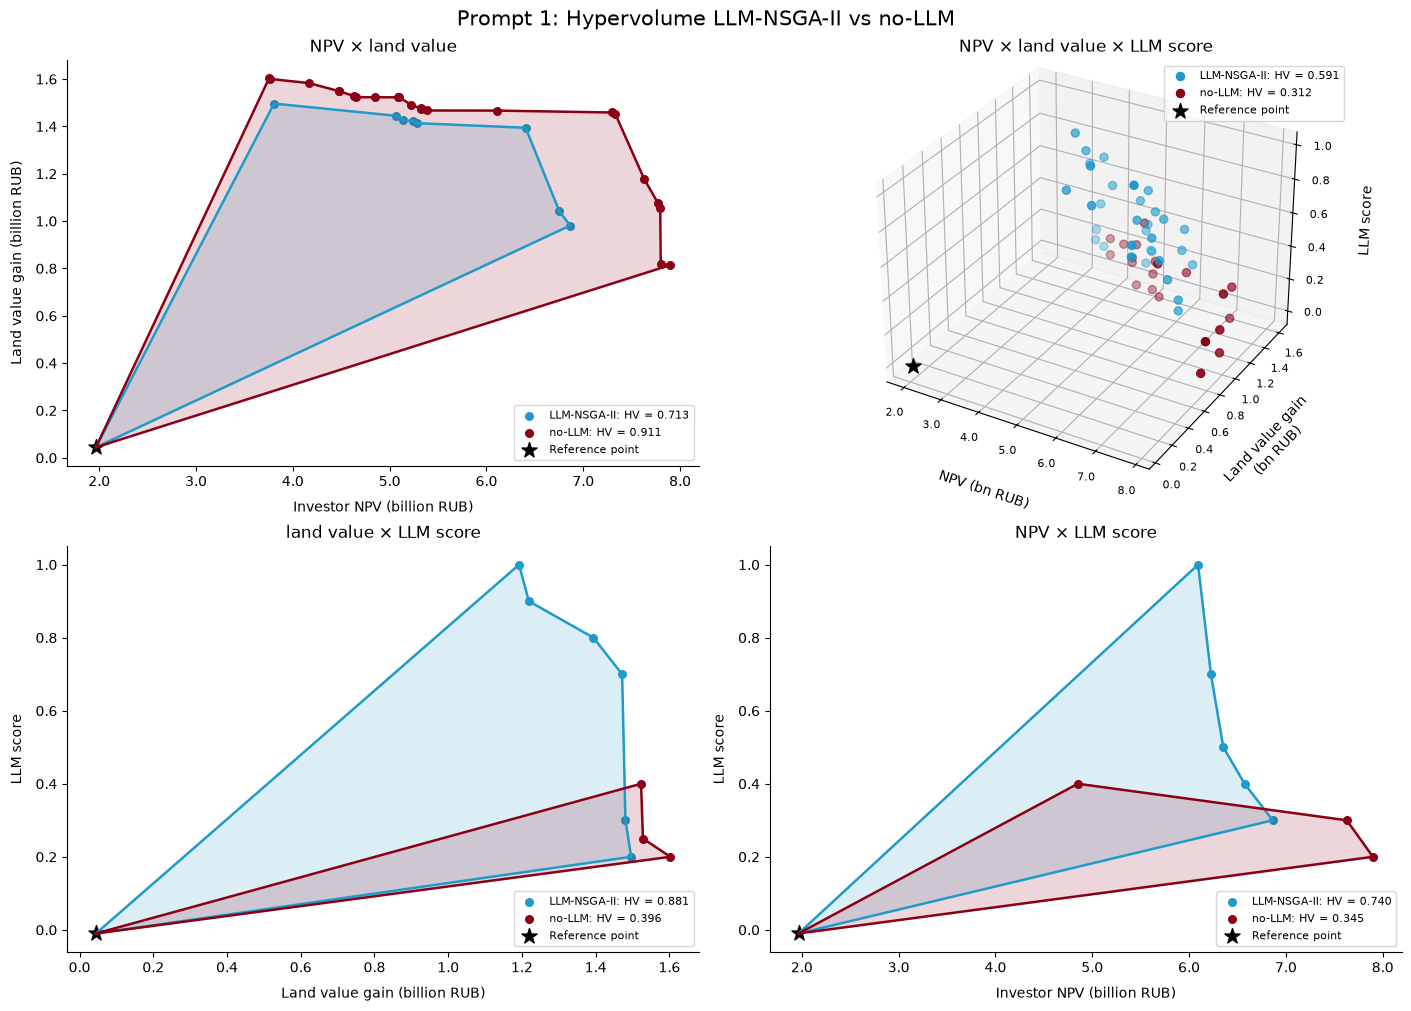

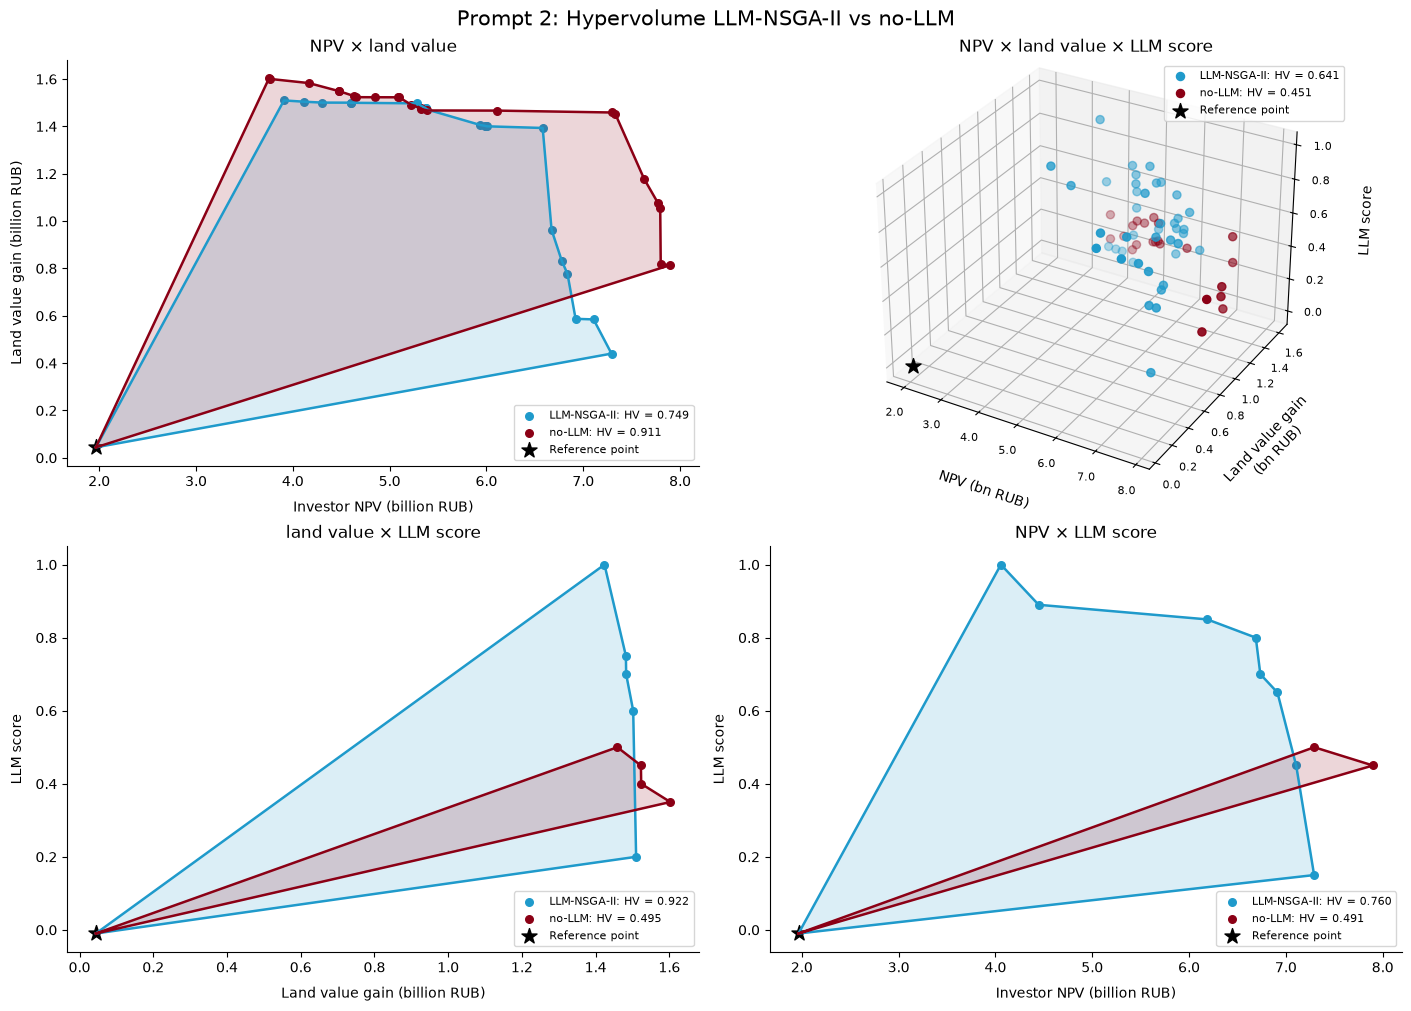

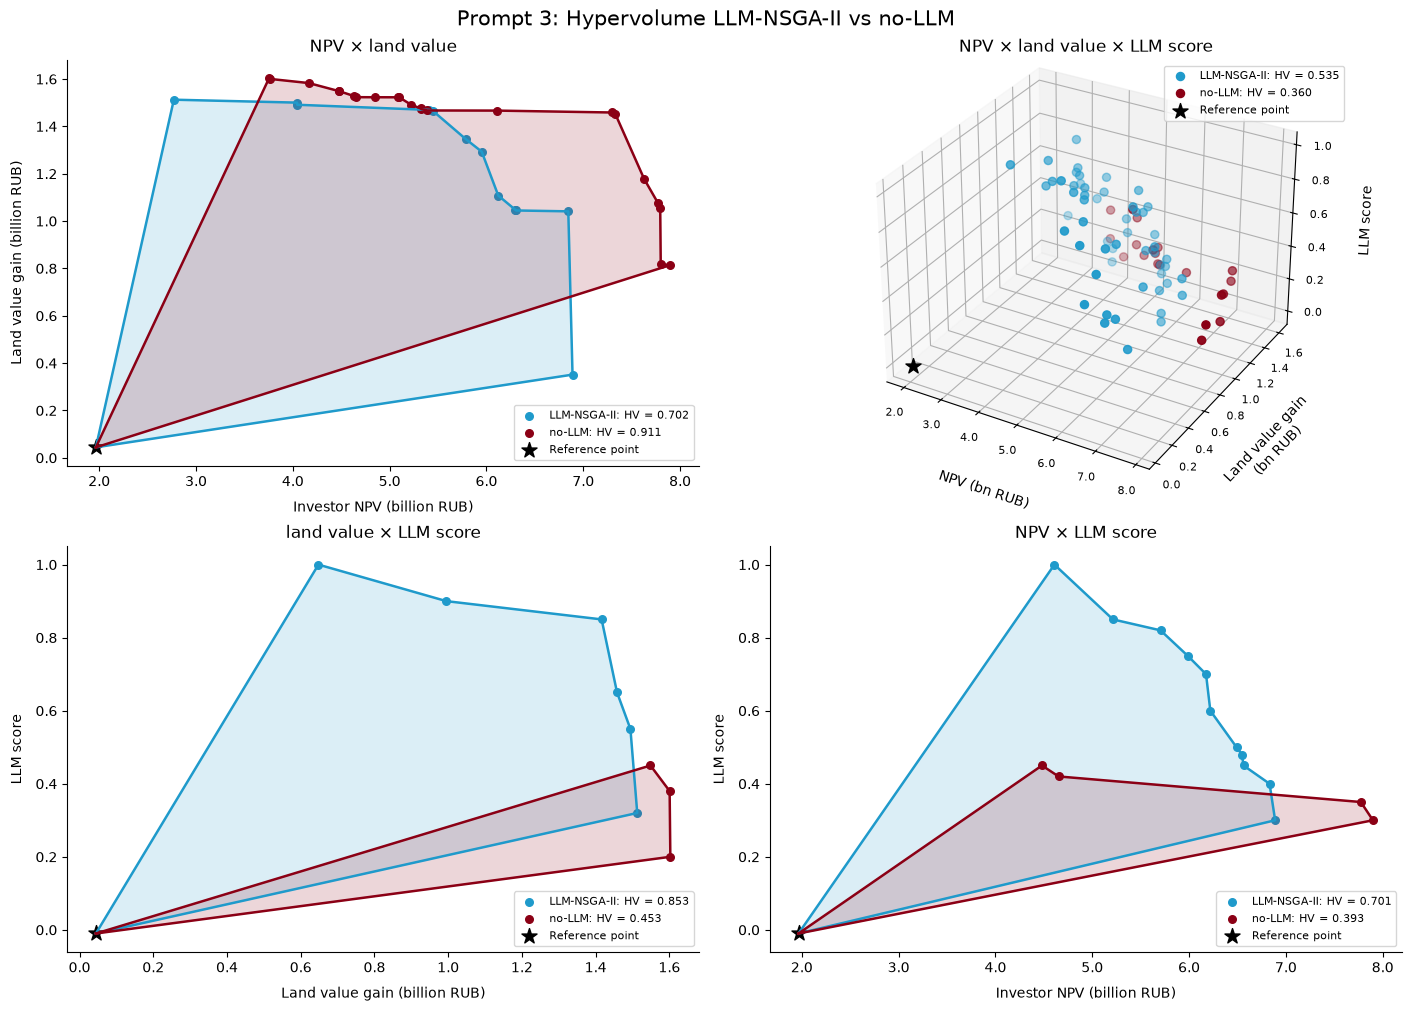

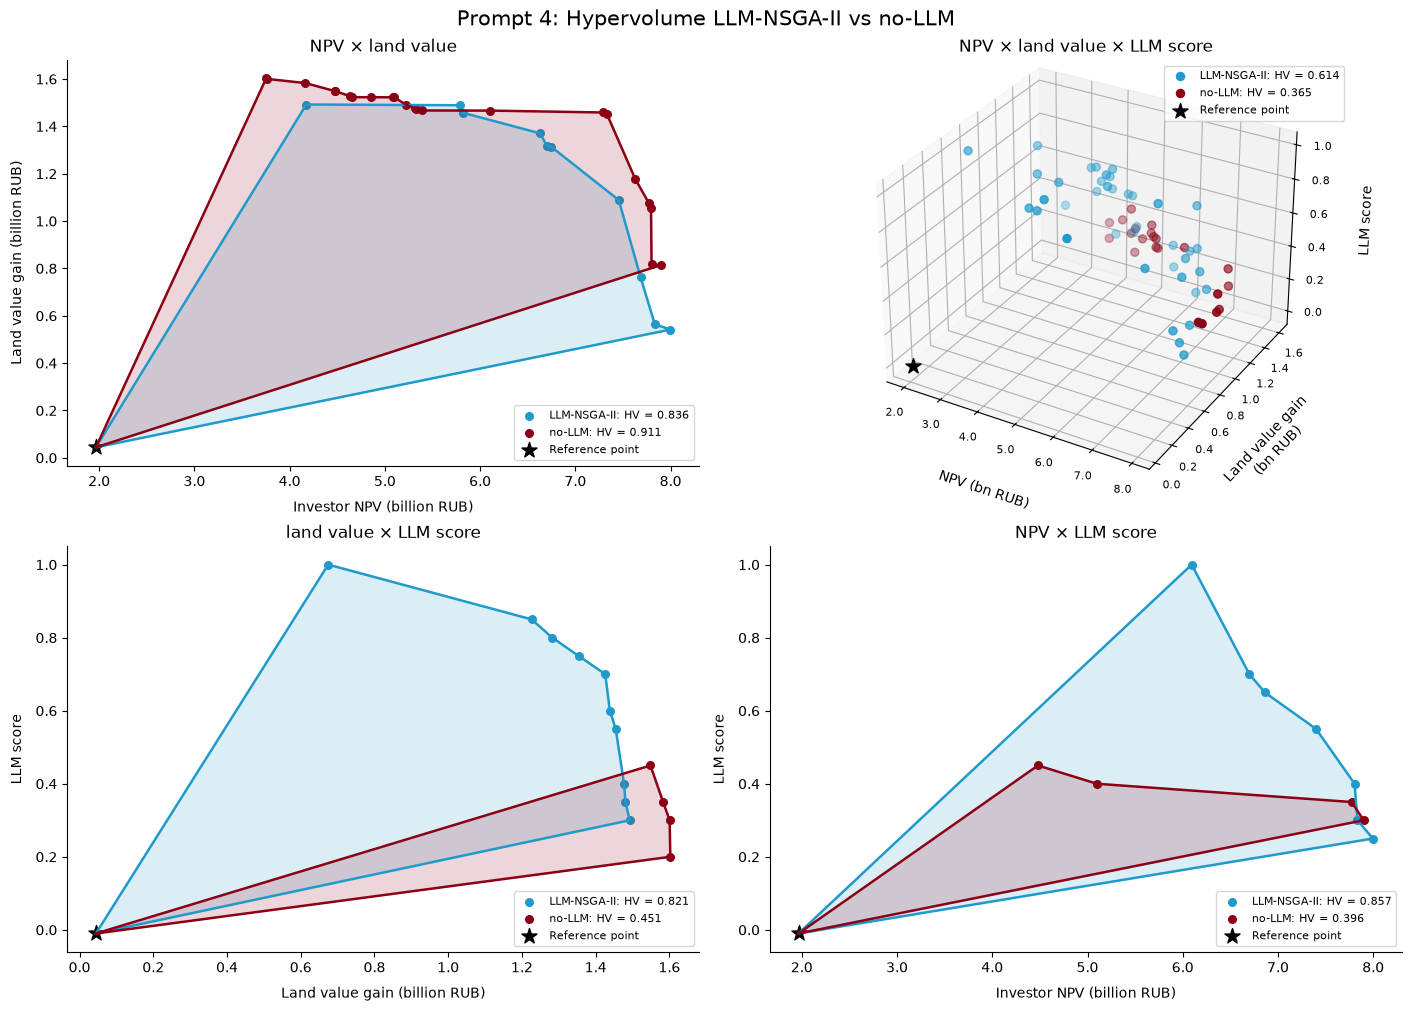

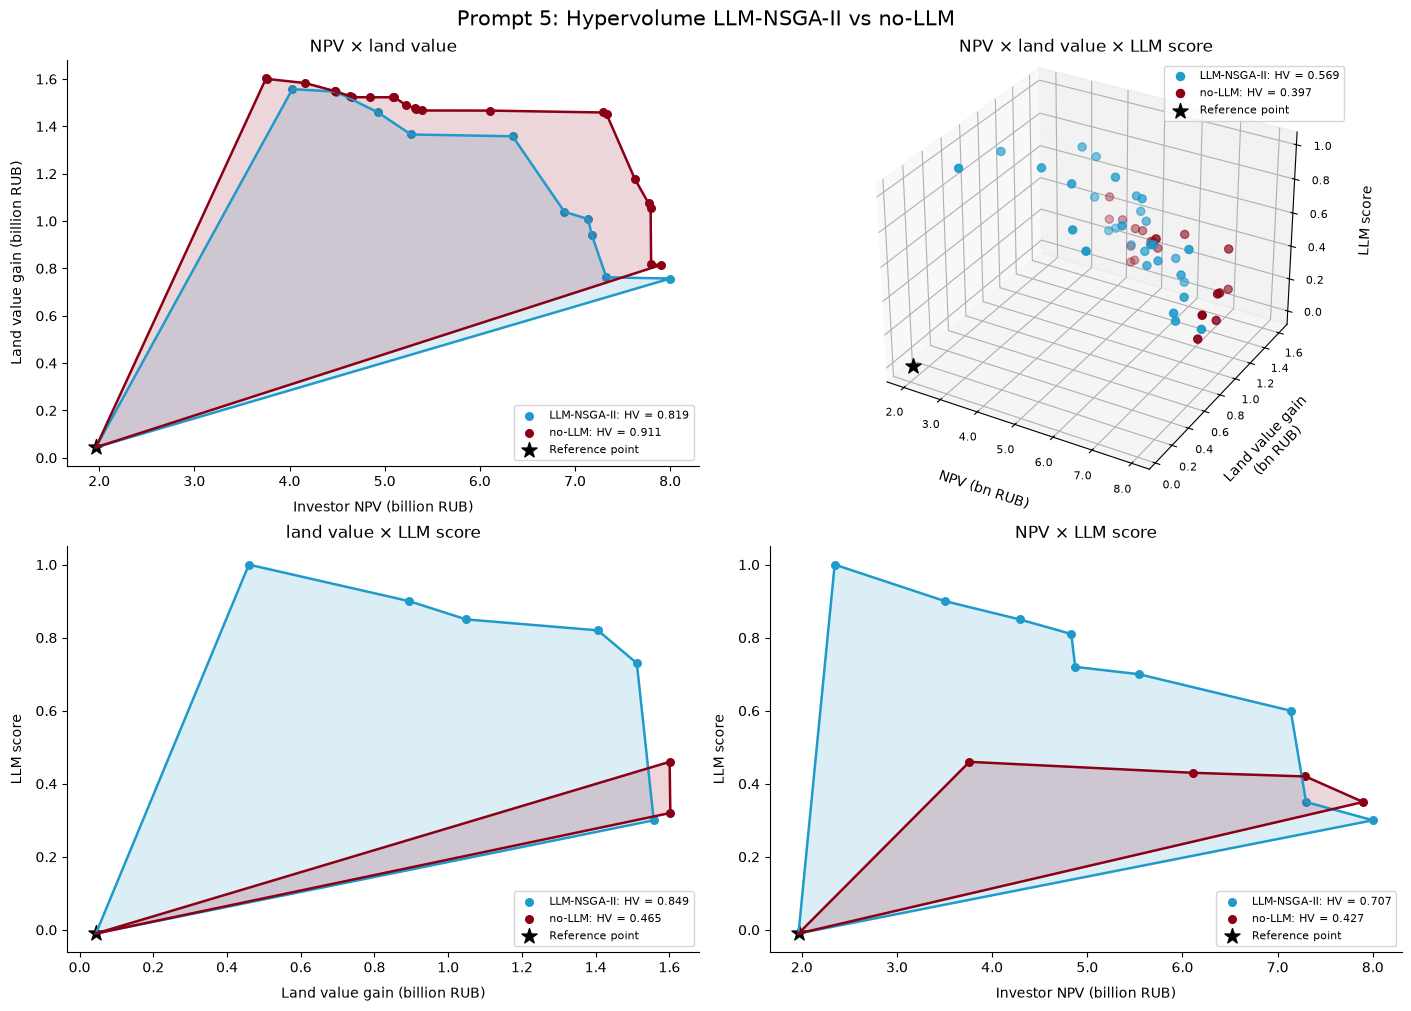

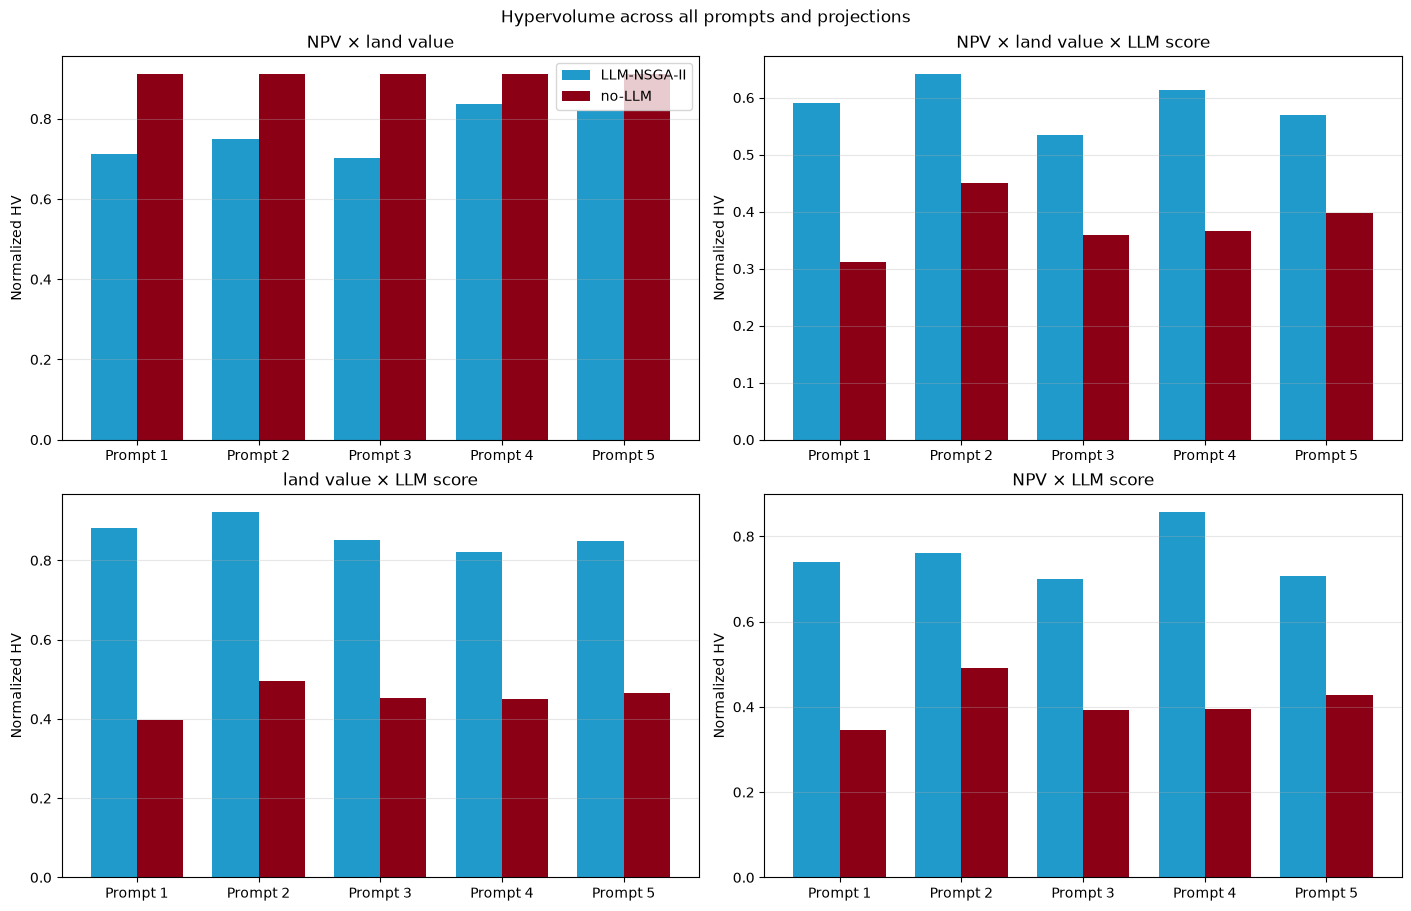

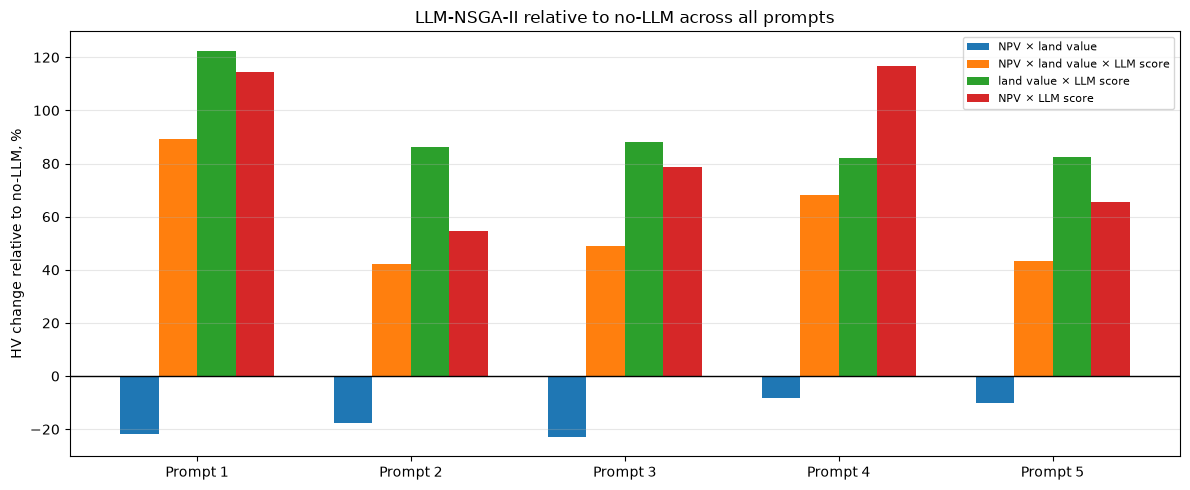

,projection,algorithm,median,IQR,mean,standard_deviation
0,NPV × LLM score,LLM-NSGA-II,0.7395,0.0529,0.7531,0.0630
1,NPV × LLM score,no-LLM,0.3957,0.0346,0.4103,0.0541
2,NPV × land value,LLM-NSGA-II,0.7488,0.1066,0.7636,0.0612
3,NPV × land value,no-LLM,0.9108,0.0000,0.9108,0.0000
4,NPV × land value × LLM score,LLM-NSGA-II,0.5907,0.0453,0.5900,0.0407
5,NPV × land value × LLM score,no-LLM,0.3654,0.0373,0.3769,0.0513
6,land value × LLM score,LLM-NSGA-II,0.8525,0.0318,0.8653,0.0382
7,land value × LLM score,no-LLM,0.4528,0.0139,0.4521,0.0360


In [8]:
from matplotlib.ticker import FuncFormatter

if "scored_selected_seed" not in globals():
    scored_selected_seed = {
        prompt_id: read_jsonl(out_root / f"prompt_{prompt_id}" / f"no_llm_scored_by_prompt_{prompt_id}_best_10_seeds.jsonl")
        for prompt_id in prompt_fronts
        if (out_root / f"prompt_{prompt_id}" / f"no_llm_scored_by_prompt_{prompt_id}_best_10_seeds.jsonl").exists()
    }


def objective_values(df, columns):
    out = df.copy()
    if "llm_score" in columns and "llm_score" not in out:
        out["llm_score"] = out["llm score"]
    for column in columns:
        out[column] = pd.to_numeric(out[column], errors="coerce")
    return out.dropna(subset=columns)[columns].to_numpy(float)


def nondominated_points(points):
    points = np.asarray(points, dtype=float)
    keep = []
    for i, point in enumerate(points):
        others = np.delete(points, i, axis=0)
        keep.append(not np.any(np.all(others >= point, axis=1) & np.any(others > point, axis=1)))
    return points[keep]


def hypervolume_2d(points, reference):
    front = np.array(sorted(nondominated_points(points), key=lambda point: point[0]))
    hv, previous_x = 0.0, reference[0]
    for x, y in front:
        hv += max(0.0, x - previous_x) * max(0.0, y - reference[1])
        previous_x = max(previous_x, x)
    return hv, front


def hypervolume_3d(points, reference):
    front = nondominated_points(points)
    xs, ys, zs = (np.unique(np.r_[reference[i], front[:, i]]) for i in range(3))
    hv = 0.0
    for x0, x1 in zip(xs[:-1], xs[1:]):
        for y0, y1 in zip(ys[:-1], ys[1:]):
            for z0, z1 in zip(zs[:-1], zs[1:]):
                if np.any(np.all(front >= [x1, y1, z1], axis=1)):
                    hv += (x1 - x0) * (y1 - y0) * (z1 - z0)
    return hv, front


specs = [
    ("NPV × land value", ["investor_npv", "land_value_gain"], hypervolume_2d),
    ("NPV × land value × LLM score", ["investor_npv", "land_value_gain", "llm_score"], hypervolume_3d),
    ("land value × LLM score", ["land_value_gain", "llm_score"], hypervolume_2d),
    ("NPV × LLM score", ["investor_npv", "llm_score"], hypervolume_2d),
]
labels = {"investor_npv": "Investor NPV (billion RUB)", "land_value_gain": "Land value gain (billion RUB)", "llm_score": "LLM score"}
labels_3d = {"investor_npv": "NPV (bn RUB)", "land_value_gain": "Land value gain\n(bn RUB)", "llm_score": "LLM score"}
currency_columns = {"investor_npv", "land_value_gain"}
billions_formatter = FuncFormatter(lambda value, _: f"{value / 1e9:.1f}")
colors = {"LLM-NSGA-II": "#1f9acb", "no-LLM": "#8b0015"}
comparisons = {
    prompt_id: {"LLM-NSGA-II": prompt_fronts[prompt_id], "no-LLM": scored_selected_seed[prompt_id]}
    for prompt_id in sorted(prompt_fronts) if prompt_id in scored_selected_seed
}

scales = {}
for projection, columns, _ in specs:
    values = np.vstack([objective_values(df, columns) for fronts in comparisons.values() for df in fronts.values()])
    reference = values.min(axis=0) - np.maximum(np.ptp(values, axis=0) * 0.01, 0.01)
    scales[projection] = reference, np.prod(values.max(axis=0) - reference)

rows, plot_data = [], {}
for prompt_id, fronts in comparisons.items():
    for projection, columns, hv_function in specs:
        reference, norm = scales[projection]
        for algorithm, df in fronts.items():
            values = objective_values(df, columns)
            hv, front = hv_function(values, reference)
            rows.append({"prompt_id": prompt_id, "projection": projection, "algorithm": algorithm,
                         "n_solutions": len(values), "n_front": len(front),
                         "hypervolume": hv, "hypervolume_norm": hv / norm if norm else np.nan})
            plot_data[prompt_id, projection, algorithm] = front, reference

hypervolume_results = pd.DataFrame(rows)

# First, four projections for each prompt.
for prompt_id in comparisons:
    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    fig.suptitle(f"Prompt {prompt_id}: Hypervolume LLM-NSGA-II vs no-LLM", fontsize=15)
    for index, (projection, columns, _) in enumerate(specs, 1):
        ax = fig.add_subplot(2, 2, index, projection="3d" if len(columns) == 3 else None)
        for algorithm, color in colors.items():
            front, reference = plot_data[prompt_id, projection, algorithm]
            hv = hypervolume_results.query("prompt_id == @prompt_id and projection == @projection and algorithm == @algorithm")["hypervolume_norm"].iat[0]
            if len(columns) == 3:
                ax.scatter(*front.T, s=34, color=color, label=f"{algorithm}: HV = {hv:.3f}")
            else:
                polygon = np.vstack([reference, front, reference])
                ax.fill(polygon[:, 0], polygon[:, 1], color=color, alpha=0.16)
                ax.plot(polygon[:, 0], polygon[:, 1], color=color, lw=1.8)
                ax.scatter(front[:, 0], front[:, 1], s=30, color=color, label=f"{algorithm}: HV = {hv:.3f}")
        ax.scatter(*reference, marker="*", s=130, color="black", label="Reference point")
        ax.set(title=projection)
        axis_labels = labels_3d if len(columns) == 3 else labels
        ax.set_xlabel(axis_labels[columns[0]], labelpad=8)
        ax.set_ylabel(axis_labels[columns[1]], labelpad=8)
        plot_axes = [ax.xaxis, ax.yaxis] + ([ax.zaxis] if len(columns) == 3 else [])
        for plot_axis, column in zip(plot_axes, columns):
            if column in currency_columns:
                plot_axis.set_major_formatter(billions_formatter)
        if len(columns) == 3:
            ax.set_zlabel(axis_labels[columns[2]], labelpad=8)
            ax.tick_params(axis="x", labelsize=8, pad=1)
            ax.tick_params(axis="y", labelsize=8, pad=1)
            ax.tick_params(axis="z", labelsize=8, pad=2)
            ax.set_box_aspect(None, zoom=1.15)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.tick_params(top=False, right=False)
        if len(columns) == 3:
            ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.15, 1.0))
        else:
            ax.legend(fontsize=8, loc="lower right")
    plt.show()

# Then, comparisons across all prompts.
projection_order = [projection for projection, _, _ in specs]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, projection in zip(axes.flat, projection_order):
    pivot = hypervolume_results.query("projection == @projection").pivot(index="prompt_id", columns="algorithm", values="hypervolume_norm")
    x, width = np.arange(len(pivot)), 0.38
    for offset, algorithm in [(-width / 2, "LLM-NSGA-II"), (width / 2, "no-LLM")]:
        ax.bar(x + offset, pivot[algorithm], width, color=colors[algorithm], label=algorithm)
    ax.set_xticks(x, [f"Prompt {i}" for i in pivot.index])
    ax.set(title=projection, ylabel="Normalized HV")
    ax.grid(axis="y", alpha=0.3)
axes.flat[0].legend()
fig.suptitle("Hypervolume across all prompts and projections")
plt.show()

comparison = hypervolume_results.pivot(index=["prompt_id", "projection"], columns="algorithm", values="hypervolume_norm").reset_index()
comparison["llm_change_pct"] = (comparison["LLM-NSGA-II"] - comparison["no-LLM"]) / comparison["no-LLM"] * 100
pct = comparison.pivot(index="prompt_id", columns="projection", values="llm_change_pct")[projection_order]
x, width = np.arange(len(pct)), 0.18
plt.figure(figsize=(12, 5))
for i, projection in enumerate(projection_order):
    plt.bar(x + (i - 1.5) * width, pct[projection], width, label=projection)
plt.axhline(0, color="black", lw=1)
plt.xticks(x, [f"Prompt {i}" for i in pct.index])
plt.ylabel("HV change relative to no-LLM, %")
plt.title("LLM-NSGA-II relative to no-LLM across all prompts")
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Median, IQR, mean, and standard deviation of normalized HV across prompts.
hypervolume_statistics = hypervolume_results.groupby(["projection", "algorithm"])["hypervolume_norm"].agg(
    median="median", q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75),
    mean="mean", standard_deviation="std").reset_index()
hypervolume_statistics["IQR"] = hypervolume_statistics["q3"] - hypervolume_statistics["q1"]
hypervolume_statistics = hypervolume_statistics[["projection", "algorithm", "median", "IQR", "mean", "standard_deviation"]]
display(hypervolume_statistics.style.format({column: "{:.4f}" for column in ["median", "IQR", "mean", "standard_deviation"]}))


# Разнообразие решений

Разнообразие оценивается только на решениях, недоминируемых в общей 2D-проекции `investor_npv × land_value_gain`. Это исключает точки, которые входили в 3D-фронт благодаря LLM score, но доминируются по двум экономическим целям.

Используются три группы показателей:

1. **Равномерность фронта:** Spacing и среднее расстояние до ближайшего соседа в общем нормализованном пространстве целей. Меньший Spacing означает более равномерное распределение.
2. **Ширина покрытия целей:** нормализованная диагональ и площадь bounding box фронта. Большие значения означают более широкое покрытие компромиссов.
3. **Разнообразие параметров решений:** расстояние Гауэра по `params_repaired`. Числовые признаки нормируются по общему диапазону, категориальные сравниваются как совпадение/различие. Дополнительно выводятся доля уникальных параметрических решений, покрытие числовых параметров и энтропия категориальных параметров.

Ни одна метрика по отдельности не доказывает большее разнообразие: вывод делается совместно по равномерности, ширине покрытия и различию параметров.


,front,n_solutions,spacing,mean_nearest_distance,objective_coverage_diagonal,objective_coverage_area,investor_npv_range,land_value_gain_range,n_parameter_solutions,parameter_unique_ratio,parameter_mean_pairwise_distance,parameter_mean_nearest_distance,parameter_numeric_coverage,parameter_categorical_entropy,land_use_count,morphotype_count
0,no LLM,22,0.0292,0.0185,0.8616,0.3545,4145980159.47,788317229.85,22,1.0000,0.1884,0.0144,0.4261,0.3368,3,2
1,prompt 2,19,0.0323,0.0291,0.8950,0.3924,3383388308.65,1069484892.81,19,0.9500,0.1775,0.0218,0.4067,0.3738,3,2
2,prompt 5,10,0.0412,0.0861,0.8429,0.3446,3971693049.80,800064246.03,10,1.0000,0.1989,0.0426,0.3877,0.3593,3,2
3,prompt 1,8,0.0834,0.0675,0.6111,0.1709,3058828727.51,515186129.06,8,1.0000,0.1274,0.0596,0.3554,0.1936,2,2
4,prompt 4,10,0.0906,0.0746,0.8881,0.3941,3822029407.17,950717356.90,10,1.0000,0.1608,0.0318,0.3711,0.2405,2,2
5,prompt 3,12,0.1314,0.0764,1.0205,0.5187,4118166643.33,1161357958.97,12,1.0000,0.1825,0.0436,0.3956,0.3971,4,2


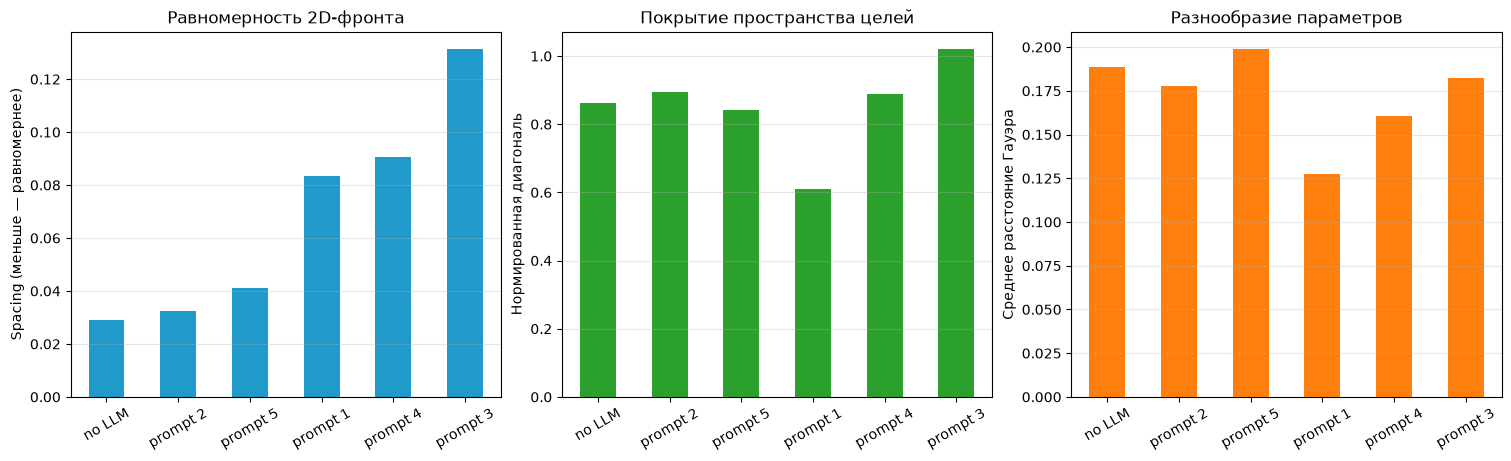

In [9]:
objective_cols = ["investor_npv", "land_value_gain"]
diversity_fronts = {
    "no LLM": numeric(selected_front, objective_cols),
    **{f"prompt {prompt_id}": numeric(front, objective_cols) for prompt_id, front in sorted(prompt_fronts.items())},
}

# Общая шкала целей для сопоставимых расстояний и покрытия.
all_objectives = pd.concat(diversity_fronts.values(), ignore_index=True)[objective_cols]
objective_min = all_objectives.min().to_numpy(float)
objective_range = np.where(np.ptp(all_objectives.to_numpy(float), axis=0) == 0, 1, np.ptp(all_objectives.to_numpy(float), axis=0))

# Общая шкала параметров для расстояния Гауэра.
parameter_scale_frames = list(diversity_fronts.values())
parameter_scale_frames.extend(
    read_jsonl(no_llm_root / f"seed_{seed}" / f"no_llm_pareto_front_{seed}.jsonl") for seed in SEEDS
)
parameter_scale_frames.extend(
    read_jsonl(llm_root / f"seed_{seed}" / f"prompt_{prompt_id}" / f"prompt_{prompt_id}_pareto_front.jsonl")
    for seed in SEEDS for prompt_id in PROMPT_IDS
)
all_parameter_rows = pd.concat(
    [pd.json_normalize(df["params_repaired"].tolist()) for df in parameter_scale_frames], ignore_index=True
)
parameter_numeric_cols = [
    column for column in all_parameter_rows
    if pd.to_numeric(all_parameter_rows[column], errors="coerce").notna().all()
]
parameter_categorical_cols = [column for column in all_parameter_rows if column not in parameter_numeric_cols]
parameter_numeric_all = all_parameter_rows[parameter_numeric_cols].apply(pd.to_numeric)
parameter_numeric_min = parameter_numeric_all.min()
parameter_numeric_range = (parameter_numeric_all.max() - parameter_numeric_min).replace(0, 1)
parameter_categorical_levels = {
    column: all_parameter_rows[column].astype(str).nunique()
    for column in parameter_categorical_cols
}


def nondominated_2d_dataframe(df):
    values = df[objective_cols].to_numpy(float)
    keep = []
    for i, point in enumerate(values):
        others = np.delete(values, i, axis=0)
        keep.append(not np.any(np.all(others >= point, axis=1) & np.any(others > point, axis=1)))
    return df.loc[keep].reset_index(drop=True)


def gower_distance_matrix(parameter_df):
    parameter_df = parameter_df.drop_duplicates().reset_index(drop=True)
    n = len(parameter_df)
    distances = np.zeros((n, n), dtype=float)
    feature_count = len(parameter_numeric_cols) + len(parameter_categorical_cols)
    if n == 0 or feature_count == 0:
        return distances

    if parameter_numeric_cols:
        numeric_values = parameter_df[parameter_numeric_cols].apply(pd.to_numeric)
        normalized = ((numeric_values - parameter_numeric_min) / parameter_numeric_range).to_numpy(float)
        distances += np.abs(normalized[:, None, :] - normalized[None, :, :]).sum(axis=2)
    for column in parameter_categorical_cols:
        values = parameter_df[column].astype(str).to_numpy()
        distances += values[:, None] != values[None, :]
    return distances / feature_count


def parameter_diversity(front_df):
    parameters = pd.json_normalize(front_df["params_repaired"].tolist())
    unique_parameters = parameters.drop_duplicates().reset_index(drop=True)
    distances = gower_distance_matrix(unique_parameters)
    if len(unique_parameters) > 1:
        upper = distances[np.triu_indices(len(distances), k=1)]
        nearest = np.where(np.eye(len(distances), dtype=bool), np.inf, distances).min(axis=1)
    else:
        upper = nearest = np.array([])

    numeric_coverage = 0.0
    if parameter_numeric_cols and len(unique_parameters):
        numeric_values = unique_parameters[parameter_numeric_cols].apply(pd.to_numeric)
        numeric_coverage = ((numeric_values.max() - numeric_values.min()) / parameter_numeric_range).mean()

    entropies = []
    for column in parameter_categorical_cols:
        level_count = parameter_categorical_levels[column]
        probabilities = unique_parameters[column].astype(str).value_counts(normalize=True).to_numpy()
        entropy = -(probabilities * np.log(probabilities)).sum()
        entropies.append(entropy / np.log(level_count) if level_count > 1 else 0.0)

    return {
        "n_parameter_solutions": len(unique_parameters),
        "parameter_unique_ratio": len(unique_parameters) / len(parameters) if len(parameters) else np.nan,
        "parameter_mean_pairwise_distance": upper.mean() if len(upper) else np.nan,
        "parameter_mean_nearest_distance": nearest.mean() if len(nearest) else np.nan,
        "parameter_numeric_coverage": numeric_coverage,
        "parameter_categorical_entropy": np.mean(entropies) if entropies else np.nan,
        "land_use_count": unique_parameters["land_use"].nunique() if "land_use" in unique_parameters else np.nan,
        "morphotype_count": unique_parameters["morphotype"].nunique() if "morphotype" in unique_parameters else np.nan,
    }


def diversity_metrics(label, df):
    front_df = nondominated_2d_dataframe(df)
    objective_values = np.unique(front_df[objective_cols].to_numpy(float), axis=0)
    normalized = (objective_values - objective_min) / objective_range
    if len(normalized) > 1:
        distances = np.linalg.norm(normalized[:, None, :] - normalized[None, :, :], axis=2)
        nearest = np.where(np.eye(len(distances), dtype=bool), np.inf, distances).min(axis=1)
    else:
        nearest = np.array([])
    normalized_ranges = np.ptp(normalized, axis=0) if len(normalized) else np.array([np.nan, np.nan])

    return {
        "front": label,
        "n_solutions": len(objective_values),
        "spacing": nearest.std(ddof=1) if len(nearest) > 1 else np.nan,
        "mean_nearest_distance": nearest.mean() if len(nearest) else np.nan,
        "objective_coverage_diagonal": np.linalg.norm(normalized_ranges),
        "objective_coverage_area": np.prod(normalized_ranges),
        "investor_npv_range": np.ptp(objective_values[:, 0]) if len(objective_values) else np.nan,
        "land_value_gain_range": np.ptp(objective_values[:, 1]) if len(objective_values) else np.nan,
        **parameter_diversity(front_df),
    }


diversity_summary = pd.DataFrame(
    diversity_metrics(label, df) for label, df in diversity_fronts.items()
).sort_values("spacing", na_position="last").reset_index(drop=True)
display(diversity_summary.style.format({
    column: "{:.4f}" for column in [
        "spacing", "mean_nearest_distance", "objective_coverage_diagonal", "objective_coverage_area",
        "parameter_unique_ratio", "parameter_mean_pairwise_distance", "parameter_mean_nearest_distance",
        "parameter_numeric_coverage", "parameter_categorical_entropy",
    ]
} | {"investor_npv_range": "{:.2f}", "land_value_gain_range": "{:.2f}"}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
diversity_summary.plot.bar(x="front", y="spacing", ax=axes[0], color="#1f9acb", legend=False)
diversity_summary.plot.bar(x="front", y="objective_coverage_diagonal", ax=axes[1], color="#2ca02c", legend=False)
diversity_summary.plot.bar(x="front", y="parameter_mean_pairwise_distance", ax=axes[2], color="#ff7f0e", legend=False)
axes[0].set(title="Равномерность 2D-фронта", xlabel="", ylabel="Spacing (меньше — равномернее)")
axes[1].set(title="Покрытие пространства целей", xlabel="", ylabel="Нормированная диагональ")
axes[2].set(title="Разнообразие параметров", xlabel="", ylabel="Среднее расстояние Гауэра")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
plt.show()


# Итоговое сравнение агрегированных prompt-фронтов

Таблица объединяет качество покрытия целевого пространства (нормированный Hypervolume) и равномерность распределения решений по двум экономическим целям (Spacing XY). Положительный $\Delta HV$ означает преимущество LLM-фронта; отрицательный $\Delta Spacing$ означает более равномерное распределение LLM-решений. Итог «лучше» ставится только при улучшении обеих метрик, «хуже» — при ухудшении обеих, иначе результат считается компромиссом.


In [10]:
hv_wide = hypervolume_results.pivot(
    index=["prompt_id", "projection"], columns="algorithm",
    values=["hypervolume_norm", "n_front"],
)
hv_wide.columns = [f"{metric}_{algorithm.lower().replace('-', '_')}" for metric, algorithm in hv_wide.columns]
aggregate_prompt_comparison = hv_wide.reset_index()
aggregate_prompt_comparison["delta_hv"] = (
    aggregate_prompt_comparison["hypervolume_norm_llm_nsga_ii"]
    - aggregate_prompt_comparison["hypervolume_norm_no_llm"]
)
aggregate_prompt_comparison["delta_hv_pct"] = (
    aggregate_prompt_comparison["delta_hv"]
    / aggregate_prompt_comparison["hypervolume_norm_no_llm"] * 100
)

spacing_by_front = diversity_summary.set_index("front")
aggregate_prompt_comparison["spacing_xy_llm"] = aggregate_prompt_comparison["prompt_id"].map(
    lambda prompt_id: spacing_by_front.loc[f"prompt {prompt_id}", "spacing"]
)
aggregate_prompt_comparison["spacing_xy_no_llm"] = spacing_by_front.loc["no LLM", "spacing"]
aggregate_prompt_comparison["delta_spacing_xy"] = (
    aggregate_prompt_comparison["spacing_xy_llm"] - aggregate_prompt_comparison["spacing_xy_no_llm"]
)
aggregate_prompt_comparison["conclusion"] = np.select(
    [
        (aggregate_prompt_comparison["delta_hv"] > 0) & (aggregate_prompt_comparison["delta_spacing_xy"] < 0),
        (aggregate_prompt_comparison["delta_hv"] < 0) & (aggregate_prompt_comparison["delta_spacing_xy"] > 0),
    ],
    ["лучше", "хуже"],
    default="компромисс",
)
aggregate_prompt_comparison = aggregate_prompt_comparison[[
    "prompt_id", "projection",
    "hypervolume_norm_llm_nsga_ii", "hypervolume_norm_no_llm", "delta_hv", "delta_hv_pct",
    "spacing_xy_llm", "spacing_xy_no_llm", "delta_spacing_xy",
    "n_front_llm_nsga_ii", "n_front_no_llm", "conclusion",
]]
display(aggregate_prompt_comparison.style.format({
    column: "{:.4f}" for column in [
        "hypervolume_norm_llm_nsga_ii", "hypervolume_norm_no_llm", "delta_hv",
        "spacing_xy_llm", "spacing_xy_no_llm", "delta_spacing_xy",
    ]
} | {"delta_hv_pct": "{:+.2f}%"}))

aggregate_effect_summary = aggregate_prompt_comparison.groupby("projection")["delta_hv_pct"].agg(
    median="median", q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75),
    mean="mean", standard_deviation="std",
    n_better=lambda x: (x > 0).sum(), n_worse=lambda x: (x < 0).sum(),
).reset_index()
aggregate_effect_summary["IQR"] = aggregate_effect_summary["q3"] - aggregate_effect_summary["q1"]
aggregate_effect_summary["share_better"] = aggregate_effect_summary["n_better"] / len(comparisons)
aggregate_effect_summary = aggregate_effect_summary[[
    "projection", "median", "IQR", "mean", "standard_deviation", "n_better", "n_worse", "share_better"
]]
display(aggregate_effect_summary.style.format({
    "median": "{:+.2f}%", "IQR": "{:.2f}", "mean": "{:+.2f}%",
    "standard_deviation": "{:.2f}", "share_better": "{:.0%}",
}))


,prompt_id,projection,hypervolume_norm_llm_nsga_ii,hypervolume_norm_no_llm,delta_hv,delta_hv_pct,spacing_xy_llm,spacing_xy_no_llm,delta_spacing_xy,n_front_llm_nsga_ii,n_front_no_llm,conclusion
0,1,NPV × LLM score,0.7395,0.3446,0.3949,+114.59%,0.0834,0.0292,0.0542,5.000000,3.000000,компромисс
1,1,NPV × land value,0.7125,0.9108,-0.1983,-21.77%,0.0834,0.0292,0.0542,8.000000,22.000000,хуже
2,1,NPV × land value × LLM score,0.5907,0.3119,0.2788,+89.40%,0.0834,0.0292,0.0542,33.000000,22.000000,компромисс
3,1,land value × LLM score,0.8811,0.3960,0.4851,+122.50%,0.0834,0.0292,0.0542,6.000000,3.000000,компромисс
4,2,NPV × LLM score,0.7602,0.4914,0.2689,+54.71%,0.0323,0.0292,0.0031,8.000000,2.000000,компромисс
5,2,NPV × land value,0.7488,0.9108,-0.1621,-17.79%,0.0323,0.0292,0.0031,20.000000,22.000000,хуже
6,2,NPV × land value × LLM score,0.6410,0.4507,0.1902,+42.20%,0.0323,0.0292,0.0031,45.000000,22.000000,компромисс
7,2,land value × LLM score,0.9222,0.4953,0.4269,+86.18%,0.0323,0.0292,0.0031,5.000000,4.000000,компромисс
8,3,NPV × LLM score,0.7010,0.3926,0.3084,+78.57%,0.1314,0.0292,0.1022,11.000000,4.000000,компромисс
9,3,NPV × land value,0.7018,0.9108,-0.2091,-22.95%,0.1314,0.0292,0.1022,12.000000,22.000000,хуже


,projection,median,IQR,mean,standard_deviation,n_better,n_worse,share_better
0,NPV × LLM score,+78.57%,49.00,+86.02%,28.31,5,0,100%
1,NPV × land value,-17.79%,11.71,-16.16%,6.71,0,5,0%
2,NPV × land value × LLM score,+48.87%,24.73,+58.37%,20.21,5,0,100%
3,land value × LLM score,+86.18%,5.68,+92.31%,17.07,5,0,100%


# Гипотеза 1 — LLM внутри оптимизации улучшает финальный Парето-фронт

**H1.** Включение `llm score` непосредственно в NSGA-II формирует финальный Парето-фронт с большим Hypervolume и более разнообразными параметрами решений, чем постфактум LLM-оценивание готового двухкритериального no-LLM фронта.

Проверка выполняется на 10 одинаковых seeds (`32–41`) и пяти промптах. Для каждой пары `prompt × seed` сравниваются LLM-NSGA-II и post-hoc no-LLM в трёх пространствах:

1. `NPV × land value × LLM score`;
2. `land value × LLM score`;
3. `NPV × LLM score`.

Для каждой проекции используется общая reference point и единый нормирующий объём. Параметрическое разнообразие сравнивается отдельно на 2D-недоминируемых экономических фронтах. Код следующей ячейки является полной проверкой H1.


,prompt_id,seed,projection,hypervolume_norm_llm_nsga_ii,hypervolume_norm_post_hoc_no_llm,n_front_llm_nsga_ii,n_front_post_hoc_no_llm,delta_hv,delta_hv_pct,llm_better
0,1,32,NPV × LLM score,0.6128,0.4045,6.000000,2.000000,+0.2083,+51.48%,True
1,1,32,NPV × land value × LLM score,0.4439,0.2880,14.000000,17.000000,+0.1559,+54.13%,True
2,1,32,land value × LLM score,0.7159,0.3731,5.000000,3.000000,+0.3429,+91.91%,True
3,1,33,NPV × LLM score,0.7822,0.2331,3.000000,2.000000,+0.5491,+235.54%,True
4,1,33,NPV × land value × LLM score,0.5940,0.2042,20.000000,16.000000,+0.3898,+190.90%,True
5,1,33,land value × LLM score,0.8306,0.2793,6.000000,3.000000,+0.5513,+197.43%,True
6,1,34,NPV × LLM score,0.7395,0.2054,6.000000,1.000000,+0.5341,+260.08%,True
7,1,34,NPV × land value × LLM score,0.5760,0.1844,20.000000,7.000000,+0.3916,+212.33%,True
8,1,34,land value × LLM score,0.7773,0.1907,4.000000,1.000000,+0.5866,+307.58%,True
9,1,35,NPV × LLM score,0.5567,0.1428,6.000000,1.000000,+0.4139,+289.89%,True


,prompt_id,projection,median_delta_hv_pct,IQR_delta_hv_pct,mean_delta_hv_pct,standard_deviation_delta_hv_pct,n_better,n_worse,share_better
0,1,NPV × LLM score,+80.20%,172.07,+117.94%,107.68,10,0,100%
1,1,NPV × land value × LLM score,+63.51%,186.38,+85.86%,104.87,6,4,60%
2,1,land value × LLM score,+91.55%,192.90,+120.82%,128.91,7,3,70%
3,2,NPV × LLM score,+45.63%,25.71,+49.65%,23.60,10,0,100%
4,2,NPV × land value × LLM score,+25.56%,35.87,+29.48%,29.38,9,1,90%
5,2,land value × LLM score,+26.98%,59.93,+38.37%,40.58,9,1,90%
6,3,NPV × LLM score,+67.25%,82.39,+91.07%,53.78,10,0,100%
7,3,NPV × land value × LLM score,+30.31%,61.65,+43.14%,41.10,9,1,90%
8,3,land value × LLM score,+65.33%,43.99,+67.01%,32.64,10,0,100%
9,4,NPV × LLM score,+40.98%,55.24,+49.33%,54.73,8,2,80%


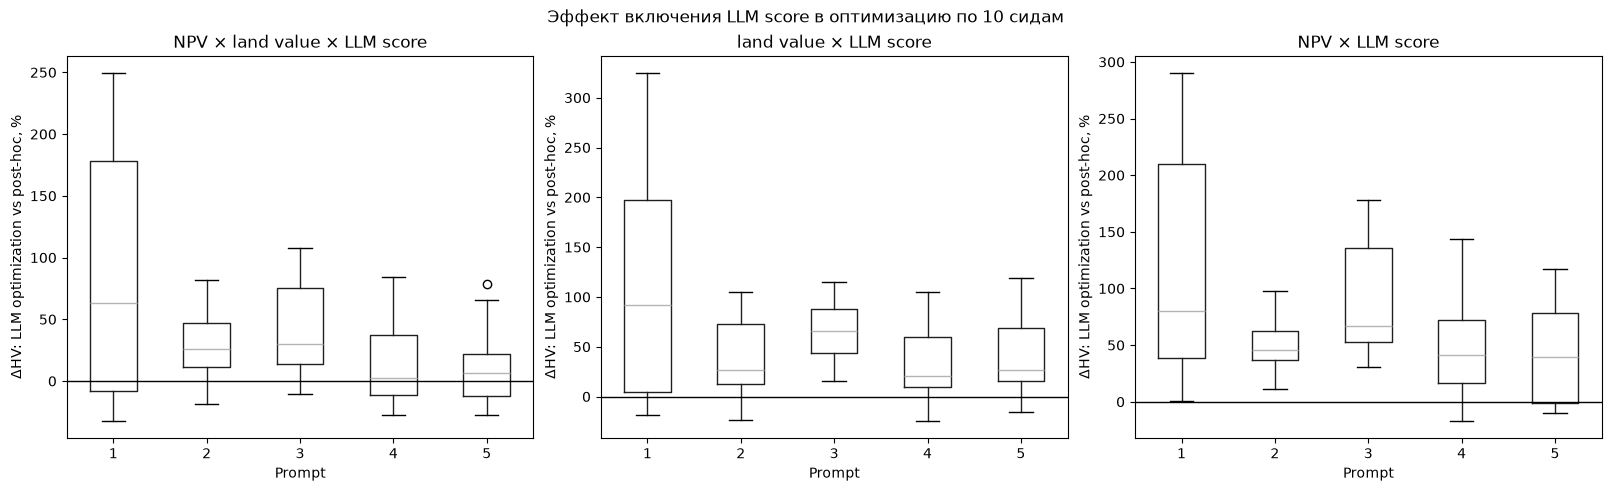

,prompt_id,median_delta_parameter_distance,median_delta_parameter_coverage,median_delta_categorical_entropy,n_more_parameter_diverse,share_more_parameter_diverse
0,1,+0.0115,+0.0103,-0.0331,5,50%
1,2,+0.0492,+0.0834,+0.1442,9,90%
2,3,+0.0558,+0.0875,+0.0523,9,90%
3,4,+0.0572,+0.0600,+0.0681,7,70%
4,5,+0.0910,+0.0503,+0.2062,8,80%


In [11]:
seed_projection_specs = specs[1:]  # 3D и две 2D-проекции с LLM score
seed_fronts = {}
for seed in SEEDS:
    for prompt_id in PROMPT_IDS:
        llm_path = llm_root / f"seed_{seed}" / f"prompt_{prompt_id}" / f"prompt_{prompt_id}_pareto_front.jsonl"
        posthoc_path = (
            no_llm_root / f"seed_{seed}" / f"prompt_{prompt_id}"
            / f"no_llm_pareto_front_{seed}_scored_by_prompt_{prompt_id}.jsonl"
        )
        seed_fronts[prompt_id, seed] = {
            "LLM-NSGA-II": read_jsonl(llm_path),
            "post-hoc no-LLM": read_jsonl(posthoc_path),
        }

# Общая reference point и нормирование отдельно для каждой проекции.
seed_projection_scales = {}
for projection, columns, _ in seed_projection_specs:
    values = np.vstack([
        objective_values(df, columns)
        for fronts in seed_fronts.values() for df in fronts.values()
    ])
    span = np.ptp(values, axis=0)
    reference = values.min(axis=0) - np.maximum(span * 0.01, 0.01)
    seed_projection_scales[projection] = reference, np.prod(values.max(axis=0) - reference)

seed_hv_rows = []
for (prompt_id, seed), fronts in seed_fronts.items():
    for projection, columns, hv_function in seed_projection_specs:
        reference, norm = seed_projection_scales[projection]
        for algorithm, df in fronts.items():
            values = objective_values(df, columns)
            hv, front = hv_function(values, reference)
            seed_hv_rows.append({
                "prompt_id": prompt_id,
                "seed": seed,
                "projection": projection,
                "algorithm": algorithm,
                "n_solutions": len(values),
                "n_front": len(front),
                "hypervolume": hv,
                "hypervolume_norm": hv / norm if norm else np.nan,
            })

seed_hypervolume_results = pd.DataFrame(seed_hv_rows)
seed_hypervolume_comparison = seed_hypervolume_results.pivot(
    index=["prompt_id", "seed", "projection"],
    columns="algorithm",
    values=["hypervolume_norm", "n_front"],
).reset_index()
seed_hypervolume_comparison.columns = [
    "_".join(str(part) for part in column if part).lower().replace("-", "_").replace(" ", "_")
    if isinstance(column, tuple) else column
    for column in seed_hypervolume_comparison.columns
]
seed_hypervolume_comparison["delta_hv"] = (
    seed_hypervolume_comparison["hypervolume_norm_llm_nsga_ii"]
    - seed_hypervolume_comparison["hypervolume_norm_post_hoc_no_llm"]
)
seed_hypervolume_comparison["delta_hv_pct"] = (
    seed_hypervolume_comparison["delta_hv"]
    / seed_hypervolume_comparison["hypervolume_norm_post_hoc_no_llm"] * 100
)
seed_hypervolume_comparison["llm_better"] = seed_hypervolume_comparison["delta_hv"] > 0

display(seed_hypervolume_comparison.style.format({
    "hypervolume_norm_llm_nsga_ii": "{:.4f}",
    "hypervolume_norm_post_hoc_no_llm": "{:.4f}",
    "delta_hv": "{:+.4f}",
    "delta_hv_pct": "{:+.2f}%",
}))

seed_hypervolume_summary = seed_hypervolume_comparison.groupby(["prompt_id", "projection"]).agg(
    median_delta_hv_pct=("delta_hv_pct", "median"),
    q1=("delta_hv_pct", lambda x: x.quantile(0.25)),
    q3=("delta_hv_pct", lambda x: x.quantile(0.75)),
    mean_delta_hv_pct=("delta_hv_pct", "mean"),
    standard_deviation_delta_hv_pct=("delta_hv_pct", "std"),
    n_better=("delta_hv", lambda x: (x > 0).sum()),
    n_worse=("delta_hv", lambda x: (x < 0).sum()),
).reset_index()
seed_hypervolume_summary["IQR_delta_hv_pct"] = seed_hypervolume_summary["q3"] - seed_hypervolume_summary["q1"]
seed_hypervolume_summary["share_better"] = seed_hypervolume_summary["n_better"] / len(SEEDS)
seed_hypervolume_summary = seed_hypervolume_summary[[
    "prompt_id", "projection", "median_delta_hv_pct", "IQR_delta_hv_pct",
    "mean_delta_hv_pct", "standard_deviation_delta_hv_pct",
    "n_better", "n_worse", "share_better",
]]
display(seed_hypervolume_summary.style.format({
    "median_delta_hv_pct": "{:+.2f}%",
    "IQR_delta_hv_pct": "{:.2f}",
    "mean_delta_hv_pct": "{:+.2f}%",
    "standard_deviation_delta_hv_pct": "{:.2f}",
    "share_better": "{:.0%}",
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (projection, _, _) in zip(axes, seed_projection_specs):
    plot_df = seed_hypervolume_comparison[seed_hypervolume_comparison["projection"] == projection]
    plot_df.boxplot(column="delta_hv_pct", by="prompt_id", ax=ax, grid=False)
    ax.axhline(0, color="black", lw=1)
    ax.set(title=projection, xlabel="Prompt", ylabel="ΔHV: LLM optimization vs post-hoc, %")
fig.suptitle("Эффект включения LLM score в оптимизацию по 10 сидам")
plt.show()

# Разнообразие параметров на сопоставимых 2D-недоминируемых фронтах.
seed_diversity_rows = []
xy_columns = ["investor_npv", "land_value_gain"]
for (prompt_id, seed), fronts in seed_fronts.items():
    metrics = {}
    for algorithm, df in fronts.items():
        front_df = nondominated_2d_dataframe(numeric(df, xy_columns))
        metrics[algorithm] = parameter_diversity(front_df)
    llm = metrics["LLM-NSGA-II"]
    posthoc = metrics["post-hoc no-LLM"]
    seed_diversity_rows.append({
        "prompt_id": prompt_id,
        "seed": seed,
        "parameter_distance_llm": llm["parameter_mean_pairwise_distance"],
        "parameter_distance_posthoc": posthoc["parameter_mean_pairwise_distance"],
        "delta_parameter_distance": llm["parameter_mean_pairwise_distance"] - posthoc["parameter_mean_pairwise_distance"],
        "parameter_coverage_llm": llm["parameter_numeric_coverage"],
        "parameter_coverage_posthoc": posthoc["parameter_numeric_coverage"],
        "delta_parameter_coverage": llm["parameter_numeric_coverage"] - posthoc["parameter_numeric_coverage"],
        "categorical_entropy_llm": llm["parameter_categorical_entropy"],
        "categorical_entropy_posthoc": posthoc["parameter_categorical_entropy"],
        "delta_categorical_entropy": llm["parameter_categorical_entropy"] - posthoc["parameter_categorical_entropy"],
    })

seed_diversity_comparison = pd.DataFrame(seed_diversity_rows)
seed_diversity_summary = seed_diversity_comparison.groupby("prompt_id").agg(
    median_delta_parameter_distance=("delta_parameter_distance", "median"),
    median_delta_parameter_coverage=("delta_parameter_coverage", "median"),
    median_delta_categorical_entropy=("delta_categorical_entropy", "median"),
    n_more_parameter_diverse=("delta_parameter_distance", lambda x: (x > 0).sum()),
).reset_index()
seed_diversity_summary["share_more_parameter_diverse"] = seed_diversity_summary["n_more_parameter_diverse"] / len(SEEDS)
display(seed_diversity_summary.style.format({
    "median_delta_parameter_distance": "{:+.4f}",
    "median_delta_parameter_coverage": "{:+.4f}",
    "median_delta_categorical_entropy": "{:+.4f}",
    "share_more_parameter_diverse": "{:.0%}",
}))


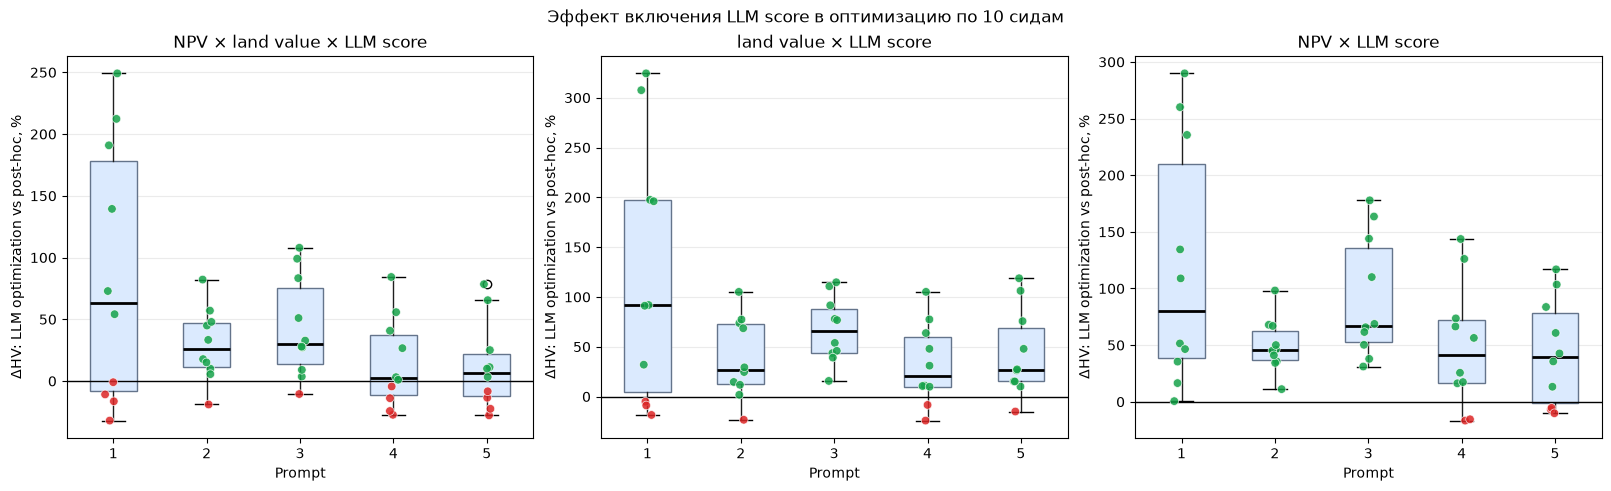

In [12]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, (projection, _, _) in zip(axes, seed_projection_specs):
    plot_df = seed_hypervolume_comparison[
        seed_hypervolume_comparison["projection"] == projection
    ]

    plot_df.boxplot(
        column="delta_hv_pct",
        by="prompt_id",
        ax=ax,
        grid=False,
        patch_artist=True,
        boxprops={"facecolor": "#dbeafe", "edgecolor": "#64748b"},
        medianprops={"color": "black", "linewidth": 2},
    )

    for prompt_id, group in plot_df.groupby("prompt_id"):
        jitter = rng.normal(0, 0.045, len(group))
        colors = np.where(
            group["delta_hv_pct"] >= 0,
            "#16a34a",
            "#dc2626",
        )
        ax.scatter(
            prompt_id + jitter,
            group["delta_hv_pct"],
            c=colors,
            s=38,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.5,
            zorder=3,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(projection)
    ax.set_xlabel("Prompt")
    ax.set_ylabel("ΔHV: LLM optimization vs post-hoc, %")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Эффект включения LLM score в оптимизацию по 10 сидам")
plt.show()

# Гипотеза 2 — LLM направляет поиск в новые области пространства решений

**H2.** На репрезентативном seed 32 включение `llm score` во время оптимизации формирует внешний трёхмерный Парето-архив с большим Hypervolume и большим параметрическим разнообразием, чем архив, построенный после post-hoc оценки всех решений обычного NSGA-II.

В отличие от H1, здесь используются не только финальные фронты, а все 600 решений, рассмотренных каждым алгоритмом. Для no-LLM журнала следующая ячейка рассчитывает `llm score` каждым из пяти промптов и сохраняет возобновляемые результаты в `seed_32/prompt_<id>/`. Первый полный запуск требует до 3000 LLM-оценок.


In [13]:
H2_SEED = 32
h2_scored_no_llm_logs = {}
h2_baseline = None

for prompt_id, prompt in prompts.items():
    source_path = no_llm_root / f"seed_{H2_SEED}" / f"no_llm_optimization_log_{H2_SEED}.jsonl"
    prompt_dir = no_llm_root / f"seed_{H2_SEED}" / f"prompt_{prompt_id}"
    prompt_dir.mkdir(exist_ok=True)
    out_path = prompt_dir / f"no_llm_optimization_log_{H2_SEED}_scored_by_prompt_{prompt_id}.jsonl"

    source_df = read_jsonl(source_path)
    df = read_jsonl(out_path) if out_path.exists() else source_df.copy()
    if len(df) != len(source_df):
        raise ValueError(f"prompt={prompt_id}: source={len(source_df)}, saved={len(df)}")
    if "seed" not in df:
        df.insert(0, "seed", H2_SEED)
    if "prompt_id" not in df:
        df.insert(1, "prompt_id", prompt_id)
    if "llm score" not in df:
        df["llm score"] = pd.NA
    df["llm score"] = pd.to_numeric(df["llm score"], errors="coerce")
    missing_indices = df.index[df["llm score"].isna()].tolist()

    print(f"[H2 | seed={H2_SEED} | prompt={prompt_id}] готово {len(df) - len(missing_indices)}/{len(df)}")
    if missing_indices:
        if h2_baseline is None:
            h2_llm = init_llm("deepseek/deepseek-v4-flash")
            h2_baseline = SingleAgentBaseline(llm=h2_llm, output_schema=Evaluation)
        scorer = StrategicAlignmentScorer(baseline=h2_baseline, prompt=prompt + json_rule)
        df.to_json(out_path, orient="records", lines=True, force_ascii=False)

        for position, idx in enumerate(missing_indices, start=1):
            row = df.loc[idx]
            scored = scorer.score_candidate(
                params_repaired=row["params_repaired"],
                land_value_gain=row["land_value_gain"],
                investor_npv=row["investor_npv"],
            )
            df.at[idx, "llm score"] = scored["score"]
            df.to_json(out_path, orient="records", lines=True, force_ascii=False)
            if position == 1 or position % 25 == 0 or position == len(missing_indices):
                print(f"  {position}/{len(missing_indices)}: llm score={float(scored['score']):.4f}")
    else:
        print(f"  уже посчитано: {out_path}")

    h2_scored_no_llm_logs[prompt_id] = df

h2_scoring_summary = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "n": len(df),
        "missing": df["llm score"].isna().sum(),
        "mean_llm_score": df["llm score"].mean(),
        "median_llm_score": df["llm score"].median(),
    }
    for prompt_id, df in h2_scored_no_llm_logs.items()
])
display(h2_scoring_summary)


[H2 | seed=32 | prompt=1] готово 600/600
  уже посчитано: nsga_2_without_llm/seed_32/prompt_1/no_llm_optimization_log_32_scored_by_prompt_1.jsonl
[H2 | seed=32 | prompt=2] готово 600/600
  уже посчитано: nsga_2_without_llm/seed_32/prompt_2/no_llm_optimization_log_32_scored_by_prompt_2.jsonl
[H2 | seed=32 | prompt=3] готово 600/600
  уже посчитано: nsga_2_without_llm/seed_32/prompt_3/no_llm_optimization_log_32_scored_by_prompt_3.jsonl
[H2 | seed=32 | prompt=4] готово 600/600
  уже посчитано: nsga_2_without_llm/seed_32/prompt_4/no_llm_optimization_log_32_scored_by_prompt_4.jsonl
[H2 | seed=32 | prompt=5] готово 600/600
  уже посчитано: nsga_2_without_llm/seed_32/prompt_5/no_llm_optimization_log_32_scored_by_prompt_5.jsonl


,prompt_id,n,missing,mean_llm_score,median_llm_score
0,1,600,0,0.177200,0.20
1,2,600,0,0.344900,0.35
2,3,600,0,0.278417,0.25
3,4,600,0,0.333133,0.35
4,5,600,0,0.357433,0.35


## Проверка гипотезы 2

Из 600 решений каждого метода отдельно строится внешний недоминируемый архив. Затем сравниваются три Hypervolume-проекции и разнообразие параметров решений. Положительные `ΔHV` и дельты разнообразия означают преимущество LLM внутри оптимизации.


[H2 | prompt=1] загружен
[H2 | prompt=2] загружен
[H2 | prompt=3] загружен
[H2 | prompt=4] загружен
[H2 | prompt=5] загружен


,prompt_id,projection,hv_llm,hv_posthoc,delta_hv,delta_hv_pct,n_archive_llm,n_archive_posthoc
0,1,NPV × land value × LLM score,0.6852,0.6960,-0.0107,-1.54%,15,35
1,1,land value × LLM score,0.8610,0.8355,+0.0255,+3.06%,5,4
2,1,NPV × LLM score,0.7921,0.8219,-0.0297,-3.62%,6,7
3,2,NPV × land value × LLM score,0.7451,0.6997,+0.0454,+6.48%,35,41
4,2,land value × LLM score,0.8870,0.8631,+0.0238,+2.76%,9,7
5,2,NPV × LLM score,0.9043,0.7265,+0.1779,+24.48%,8,6
6,3,NPV × land value × LLM score,0.5787,0.7546,-0.1759,-23.31%,43,34
7,3,land value × LLM score,0.7280,0.8768,-0.1488,-16.97%,10,8
8,3,NPV × LLM score,0.8362,0.7842,+0.0521,+6.64%,7,8
9,4,NPV × land value × LLM score,0.7897,0.7415,+0.0482,+6.50%,28,39


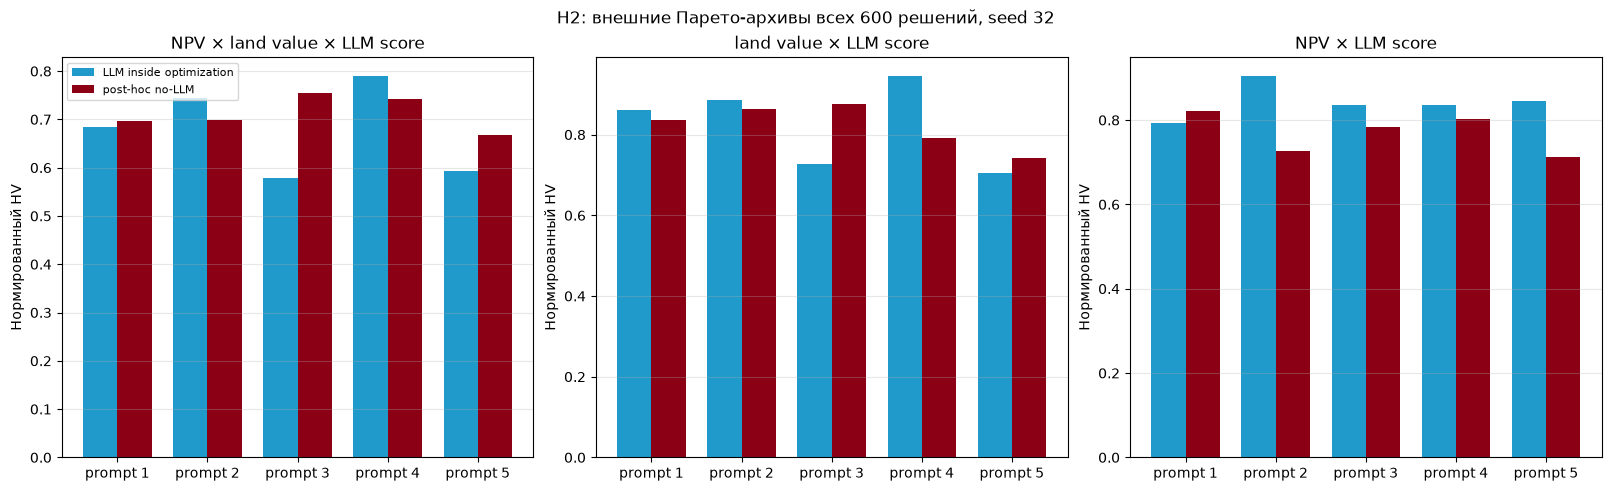

,prompt_id,n_archive_llm,n_archive_posthoc,delta_parameter_distance,delta_parameter_coverage,delta_categorical_entropy
0,1,15,35,+0.1876,+0.1588,+0.5059
1,2,35,41,+0.2640,+0.3351,+0.5964
2,3,43,34,+0.1407,+0.3454,+0.4128
3,4,28,39,+0.1312,+0.5850,+0.1403
4,5,36,38,+0.1345,+0.1998,+0.4304


In [14]:
H2_SEED = 32
h2_scored_no_llm_logs = {}
h2_fronts = {}
for prompt_id in PROMPT_IDS:
    llm_log_path = (
        llm_root / f"seed_{H2_SEED}" / f"prompt_{prompt_id}"
        / f"prompt_{prompt_id}_optimization_log.jsonl"
    )
    posthoc_path = (
        no_llm_root / f"seed_{H2_SEED}" / f"prompt_{prompt_id}"
        / f"no_llm_optimization_log_{H2_SEED}_scored_by_prompt_{prompt_id}.jsonl"
    )
    if not llm_log_path.exists() or not posthoc_path.exists():
        print(f"[H2 | prompt={prompt_id}] пропущен: нет одного из файлов")
        continue

    llm_df = read_jsonl(llm_log_path)
    posthoc_df = read_jsonl(posthoc_path)
    if any(df.empty or "llm score" not in df or df["llm score"].isna().any() for df in (llm_df, posthoc_df)):
        print(f"[H2 | prompt={prompt_id}] пропущен: LLM-оценки посчитаны не полностью")
        continue

    h2_scored_no_llm_logs[prompt_id] = posthoc_df
    h2_fronts[prompt_id] = {
        "LLM inside optimization": llm_df,
        "post-hoc no-LLM": posthoc_df,
    }
    print(f"[H2 | prompt={prompt_id}] загружен")

h2_projection_specs = specs[1:]
h2_hv_rows = []
for prompt_id, fronts in h2_fronts.items():
    for projection, columns, hv_function in h2_projection_specs:
        all_values = np.vstack([objective_values(df, columns) for df in fronts.values()])
        span = np.ptp(all_values, axis=0)
        reference = all_values.min(axis=0) - np.maximum(span * 0.01, 0.01)
        norm = np.prod(all_values.max(axis=0) - reference)
        metrics = {}
        for algorithm, df in fronts.items():
            hv, archive = hv_function(objective_values(df, columns), reference)
            metrics[algorithm] = {"hv": hv / norm if norm else np.nan, "n_archive": len(archive)}
        llm = metrics["LLM inside optimization"]
        posthoc = metrics["post-hoc no-LLM"]
        h2_hv_rows.append({
            "prompt_id": prompt_id,
            "projection": projection,
            "hv_llm": llm["hv"],
            "hv_posthoc": posthoc["hv"],
            "delta_hv": llm["hv"] - posthoc["hv"],
            "delta_hv_pct": (llm["hv"] - posthoc["hv"]) / posthoc["hv"] * 100 if posthoc["hv"] else np.nan,
            "n_archive_llm": llm["n_archive"],
            "n_archive_posthoc": posthoc["n_archive"],
        })

h2_hypervolume_comparison = pd.DataFrame(h2_hv_rows, columns=[
    "prompt_id", "projection", "hv_llm", "hv_posthoc", "delta_hv",
    "delta_hv_pct", "n_archive_llm", "n_archive_posthoc",
])
display(h2_hypervolume_comparison.style.format({
    "hv_llm": "{:.4f}", "hv_posthoc": "{:.4f}",
    "delta_hv": "{:+.4f}", "delta_hv_pct": "{:+.2f}%",
}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (projection, _, _) in zip(axes, h2_projection_specs):
    plot_df = h2_hypervolume_comparison[h2_hypervolume_comparison["projection"] == projection]
    x = np.arange(len(plot_df))
    width = 0.38
    ax.bar(x - width / 2, plot_df["hv_llm"], width, color="#1f9acb", label="LLM inside optimization")
    ax.bar(x + width / 2, plot_df["hv_posthoc"], width, color="#8b0015", label="post-hoc no-LLM")
    ax.set_xticks(x, [f"prompt {prompt_id}" for prompt_id in plot_df["prompt_id"]])
    ax.set(title=projection, ylabel="Нормированный HV")
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle(f"H2: внешние Парето-архивы всех 600 решений, seed {H2_SEED}")
plt.show()


def h2_parameter_metrics(front_df, shared_parameters):
    parameters = pd.json_normalize(front_df["params_repaired"].tolist()).drop_duplicates().reset_index(drop=True)
    numeric_cols = [
        column for column in shared_parameters
        if pd.to_numeric(shared_parameters[column], errors="coerce").notna().all()
    ]
    categorical_cols = [column for column in shared_parameters if column not in numeric_cols]
    numeric_all = shared_parameters[numeric_cols].apply(pd.to_numeric)
    numeric_min = numeric_all.min()
    numeric_range = (numeric_all.max() - numeric_min).replace(0, 1)
    n = len(parameters)
    distances = np.zeros((n, n), dtype=float)
    feature_count = len(numeric_cols) + len(categorical_cols)
    if numeric_cols:
        normalized = ((parameters[numeric_cols].apply(pd.to_numeric) - numeric_min) / numeric_range).to_numpy(float)
        distances += np.abs(normalized[:, None, :] - normalized[None, :, :]).sum(axis=2)
    for column in categorical_cols:
        values = parameters[column].astype(str).to_numpy()
        distances += values[:, None] != values[None, :]
    distances /= feature_count
    pairwise = distances[np.triu_indices(n, k=1)] if n > 1 else np.array([])
    numeric_coverage = (
        (parameters[numeric_cols].apply(pd.to_numeric).max() - parameters[numeric_cols].apply(pd.to_numeric).min())
        / numeric_range
    ).mean()
    entropies = []
    for column in categorical_cols:
        probabilities = parameters[column].astype(str).value_counts(normalize=True).to_numpy()
        levels = shared_parameters[column].astype(str).nunique()
        entropy = -(probabilities * np.log(probabilities)).sum()
        entropies.append(entropy / np.log(levels) if levels > 1 else 0.0)
    return {
        "n_archive": len(front_df),
        "parameter_distance": pairwise.mean() if len(pairwise) else np.nan,
        "parameter_coverage": numeric_coverage,
        "categorical_entropy": np.mean(entropies) if entropies else np.nan,
    }


h2_diversity_rows = []
for prompt_id, fronts in h2_fronts.items():
    archive_frames = {
        algorithm: nondominated(df, ["investor_npv", "land_value_gain", "llm score"])
        for algorithm, df in fronts.items()
    }
    shared_parameters = pd.concat(
        [pd.json_normalize(df["params_repaired"].tolist()) for df in archive_frames.values()],
        ignore_index=True,
    )
    metrics = {
        algorithm: h2_parameter_metrics(df, shared_parameters)
        for algorithm, df in archive_frames.items()
    }
    llm = metrics["LLM inside optimization"]
    posthoc = metrics["post-hoc no-LLM"]
    h2_diversity_rows.append({
        "prompt_id": prompt_id,
        "n_archive_llm": llm["n_archive"],
        "n_archive_posthoc": posthoc["n_archive"],
        "delta_parameter_distance": llm["parameter_distance"] - posthoc["parameter_distance"],
        "delta_parameter_coverage": llm["parameter_coverage"] - posthoc["parameter_coverage"],
        "delta_categorical_entropy": llm["categorical_entropy"] - posthoc["categorical_entropy"],
    })

h2_diversity_comparison = pd.DataFrame(h2_diversity_rows, columns=[
    "prompt_id", "n_archive_llm", "n_archive_posthoc",
    "delta_parameter_distance", "delta_parameter_coverage", "delta_categorical_entropy",
])
display(h2_diversity_comparison.style.format({
    "delta_parameter_distance": "{:+.4f}",
    "delta_parameter_coverage": "{:+.4f}",
    "delta_categorical_entropy": "{:+.4f}",
}))


## Направление и эффективность поиска с LLM

Финальный Hypervolume показывает только итог, но не отвечает на вопрос, **как** алгоритм двигался к нему. Ниже для каждого промпта после каждого поколения строится накопленный трёхмерный Hypervolume по всем уже рассмотренным решениям (`NPV × land value × LLM score`). LLM-guided NSGA-II сравнивается с тем же no-LLM журналом, оценённым post-hoc тем же промптом.

Используются три взаимодополняющих критерия:

1. `delta_final_hv` — преимущество LLM в конце оптимизации;
2. `delta_auc_hv` — преимущество LLM на всём пути поиска (площадь под кривой сходимости);
3. `share_generations_llm_better` — доля поколений, после которых LLM-архив лучше baseline.

LLM считается лучше только при положительных финальной и интегральной дельтах; хуже — когда обе отрицательны. В остальных случаях результат смешанный.

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_4873/1345147657.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  llm_auc = np.trapz(llm_curve, dx=1) / max(n_generations - 1, 1)
/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_4873/1345147657.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posthoc_auc = np.trapz(posthoc_curve, dx=1) / max(n_generations - 1, 1)
/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_4873/1345147657.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  llm_auc = np.trapz(llm_curve, dx=1) / max(n_generations - 1, 1)
/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_4873/1345147657.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid`

,prompt_id,initial_hv_llm,initial_hv_posthoc,final_hv_llm,final_hv_posthoc,delta_final_hv,delta_auc_hv,share_generations_llm_better,conclusion
0,1,0.0736,0.0901,0.6852,0.6960,-0.0107,-0.0894,0%,хуже
1,2,0.0987,0.1035,0.7451,0.6997,+0.0454,-0.0763,7%,смешанный результат
2,3,0.0855,0.0875,0.5787,0.7546,-0.1759,-0.1137,3%,хуже
3,4,0.1160,0.0892,0.7897,0.7415,+0.0482,+0.0766,97%,лучше
4,5,0.0904,0.0907,0.5938,0.6675,-0.0737,-0.0915,0%,хуже


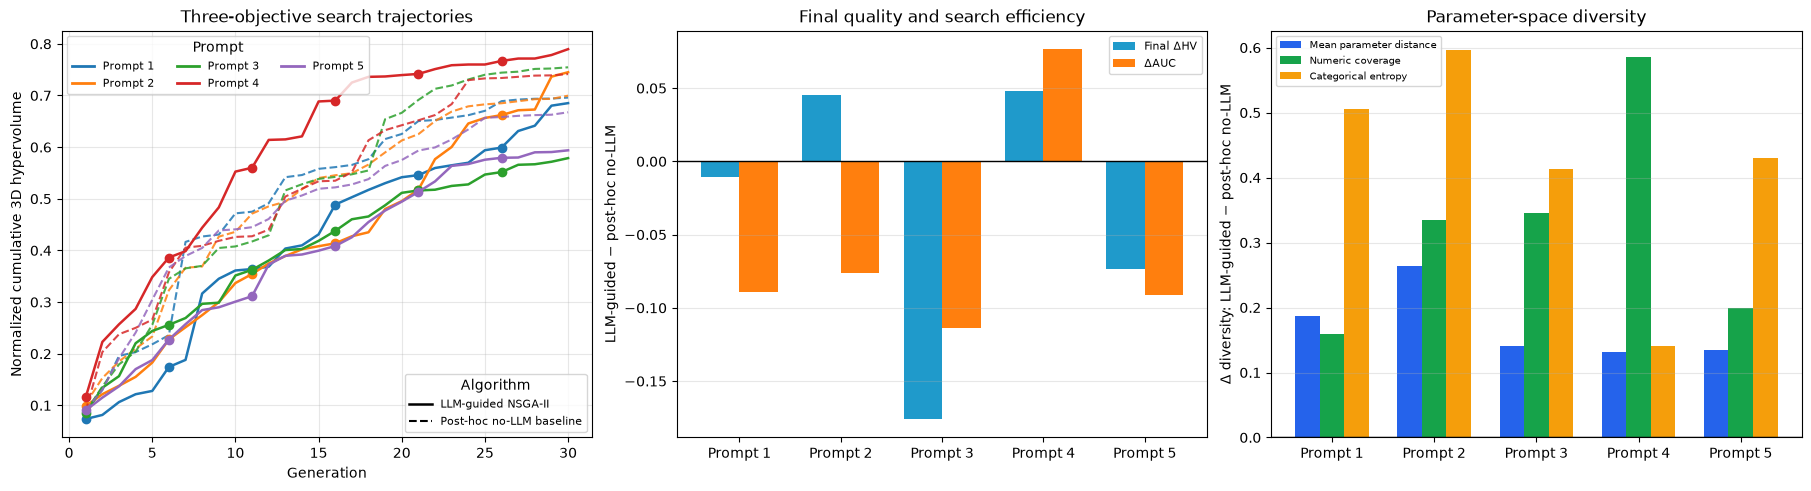

In [19]:
from pymoo.indicators.hv import HV

H2_POPULATION_SIZE = 20
H2_DIRECTION_OBJECTIVES = ["investor_npv", "land_value_gain", "llm score"]
h2_direction_rows = []
h2_direction_curves = []

for prompt_id, fronts in h2_fronts.items():
    values_by_algorithm = {}
    for algorithm, df in fronts.items():
        ordered = df.sort_values("eval_id")
        values = ordered[H2_DIRECTION_OBJECTIVES].apply(pd.to_numeric, errors="coerce")
        if values.isna().any().any() or len(values) % H2_POPULATION_SIZE:
            raise ValueError(
                f"prompt={prompt_id}, algorithm={algorithm}: "
                "ожидалось полное число поколений без пропущенных целей"
            )
        values_by_algorithm[algorithm] = values.to_numpy(float)

    generation_counts = {len(values) // H2_POPULATION_SIZE for values in values_by_algorithm.values()}
    if len(generation_counts) != 1:
        raise ValueError(f"prompt={prompt_id}: разное число поколений у алгоритмов")
    n_generations = generation_counts.pop()

    # Одна шкала внутри prompt делает LLM и post-hoc baseline строго сопоставимыми.
    all_values = np.vstack(list(values_by_algorithm.values()))
    span = np.ptp(all_values, axis=0)
    reference = all_values.min(axis=0) - np.maximum(0.01 * span, [1.0, 1.0, 0.01])
    scale = np.where(all_values.max(axis=0) > reference, all_values.max(axis=0) - reference, 1.0)
    hv_indicator = HV(ref_point=np.ones(3))

    prompt_curves = {}
    for algorithm, values in values_by_algorithm.items():
        minimization_values = 1.0 - (values - reference) / scale
        curve = np.array([
            hv_indicator(minimization_values[:generation * H2_POPULATION_SIZE])
            for generation in range(1, n_generations + 1)
        ])
        if np.any(np.diff(curve) < -1e-12):
            raise AssertionError("Накопленный Hypervolume не должен уменьшаться")
        prompt_curves[algorithm] = curve
        h2_direction_curves.extend({
            "prompt_id": prompt_id,
            "algorithm": algorithm,
            "generation": generation,
            "hypervolume_norm": hv,
        } for generation, hv in enumerate(curve, start=1))

    llm_curve = prompt_curves["LLM inside optimization"]
    posthoc_curve = prompt_curves["post-hoc no-LLM"]
    delta_curve = llm_curve - posthoc_curve
    llm_auc = np.trapz(llm_curve, dx=1) / max(n_generations - 1, 1)
    posthoc_auc = np.trapz(posthoc_curve, dx=1) / max(n_generations - 1, 1)
    delta_final = delta_curve[-1]
    delta_auc = llm_auc - posthoc_auc
    conclusion = (
        "лучше" if delta_final > 0 and delta_auc > 0
        else "хуже" if delta_final < 0 and delta_auc < 0
        else "смешанный результат"
    )
    h2_direction_rows.append({
        "prompt_id": prompt_id,
        "initial_hv_llm": llm_curve[0],
        "initial_hv_posthoc": posthoc_curve[0],
        "final_hv_llm": llm_curve[-1],
        "final_hv_posthoc": posthoc_curve[-1],
        "delta_final_hv": delta_final,
        "delta_auc_hv": delta_auc,
        "share_generations_llm_better": np.mean(delta_curve > 0),
        "conclusion": conclusion,
    })

h2_direction_comparison = pd.DataFrame(h2_direction_rows)
h2_direction_curve_df = pd.DataFrame(h2_direction_curves)
display(h2_direction_comparison.style.format({
    "initial_hv_llm": "{:.4f}",
    "initial_hv_posthoc": "{:.4f}",
    "final_hv_llm": "{:.4f}",
    "final_hv_posthoc": "{:.4f}",
    "delta_final_hv": "{:+.4f}",
    "delta_auc_hv": "{:+.4f}",
    "share_generations_llm_better": "{:.0%}",
}))

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
prompt_ids = sorted(h2_fronts)
for color_index, prompt_id in enumerate(prompt_ids):
    color = f"C{color_index}"
    prompt_curves = h2_direction_curve_df[h2_direction_curve_df["prompt_id"] == prompt_id]
    llm = prompt_curves[prompt_curves["algorithm"] == "LLM inside optimization"]
    posthoc = prompt_curves[prompt_curves["algorithm"] == "post-hoc no-LLM"]
    axes[0].plot(
        llm["generation"], llm["hypervolume_norm"],
        color=color, linestyle="-", marker="o", markevery=5, lw=1.8,
    )
    axes[0].plot(
        posthoc["generation"], posthoc["hypervolume_norm"],
        color=color, linestyle="--", lw=1.5, alpha=0.85,
    )
axes[0].set(
    title="Three-objective search trajectories",
    xlabel="Generation", ylabel="Normalized cumulative 3D hypervolume",
)
axes[0].grid(alpha=0.3)
prompt_legend = axes[0].legend(
    handles=[Line2D([0], [0], color=f"C{i}", lw=2, label=f"Prompt {prompt_id}")
             for i, prompt_id in enumerate(prompt_ids)],
    title="Prompt", ncol=3, fontsize=8, loc="upper left",
)
axes[0].add_artist(prompt_legend)
axes[0].legend(
    handles=[
        Line2D([0], [0], color="black", lw=1.8, linestyle="-", label="LLM-guided NSGA-II"),
        Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="Post-hoc no-LLM baseline"),
    ],
    title="Algorithm", fontsize=8, loc="lower right",
)

x = np.arange(len(h2_direction_comparison))
width = 0.38
axes[1].bar(
    x - width / 2, h2_direction_comparison["delta_final_hv"], width,
    label="Final ΔHV", color="#1f9acb",
)
axes[1].bar(
    x + width / 2, h2_direction_comparison["delta_auc_hv"], width,
    label="ΔAUC", color="#ff7f0e",
)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x, [f"Prompt {prompt_id}" for prompt_id in h2_direction_comparison["prompt_id"]])
axes[1].set(title="Final quality and search efficiency", ylabel="LLM-guided − post-hoc no-LLM")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(fontsize=8)

diversity_plot = h2_diversity_comparison.sort_values("prompt_id").reset_index(drop=True)
diversity_metrics = [
    ("delta_parameter_distance", "Mean parameter distance", "#2563eb"),
    ("delta_parameter_coverage", "Numeric coverage", "#16a34a"),
    ("delta_categorical_entropy", "Categorical entropy", "#f59e0b"),
]
diversity_width = 0.24
for metric_index, (column, label, color) in enumerate(diversity_metrics):
    axes[2].bar(
        x + (metric_index - 1) * diversity_width,
        diversity_plot[column],
        diversity_width,
        label=label,
        color=color,
    )
axes[2].axhline(0, color="black", lw=1)
axes[2].set_xticks(x, [f"Prompt {prompt_id}" for prompt_id in diversity_plot["prompt_id"]])
axes[2].set(
    title="Parameter-space diversity",
    ylabel="Δ diversity: LLM-guided − post-hoc no-LLM",
)
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend(fontsize=7.5)
plt.show()


# H2 — Urban-planning direction experiment

This confirmatory experiment tests whether Prompt 3 (active urban life) directs NSGA-II toward a larger and more varied set of **planning-comfort candidates**, rather than merely increasing the model's own score. The treatment is Prompt-3 LLM-guided NSGA-II; the control is the same NSGA-II without LLM. Both use the same 10 seeds (`32–41`), 30 generations, population size 20, and evaluation budget of 600 scenarios per seed.

The independent planning proxy is fixed before comparing algorithms and gives equal weight to four interpretable components available in every scenario:

1. functional-mix entropy;
2. business + recreation share (active-use potential);
3. unbuilt-ground potential (`1 − normalized GSI`);
4. human-scale massing potential (`1 − normalized floor count`).

A *high-comfort candidate* is a scenario above the pooled 75th percentile of the no-LLM proxy. This threshold is defined only from the control distribution and is not tuned to the LLM results. Direction is measured by the cumulative top-20 proxy trajectory; variation is measured by the yield of high-comfort candidates and the number of observed `land_use × morphotype` combinations among them.

**Decision rule.** Evidence supports H2 in planning terms when the LLM improves both the mean proxy and the high-comfort yield in at least 8 of 10 paired seeds, with a one-sided exact sign-test $p<0.05$. Typological richness is a supporting endpoint, not a required endpoint.

**Scope caveat.** This is a transparent diagnostic proxy, not a validated urban-comfort standard. It does not directly measure daylight, noise, pedestrian connectivity, service accessibility, public-space quality, or resident experience. Results therefore support a claim about the *direction of the generated development scenarios*, not about experienced comfort.

,high_comfort_threshold,threshold_definition
0,0.370852,75th percentile of pooled no-LLM proxy


,metric,median_delta,mean_delta,llm_better_seeds,n_seeds,sign_test_p_one_sided
0,Mean planning-comfort proxy,+0.0399,+0.0436,10,10,0.0010
1,High-comfort candidate yield,+157.0000,+176.9000,10,10,0.0010
2,Comfortable typology richness,+3.5000,+4.4000,8,10,0.0547
3,Functional-mix entropy,+0.0035,+0.0312,7,10,0.1719
4,Active-use share,+0.0435,+0.0406,9,10,0.0107
5,Unbuilt-ground potential,+0.0465,+0.0590,10,10,0.0010
6,Human-scale massing potential,+0.0518,+0.0437,9,10,0.0107


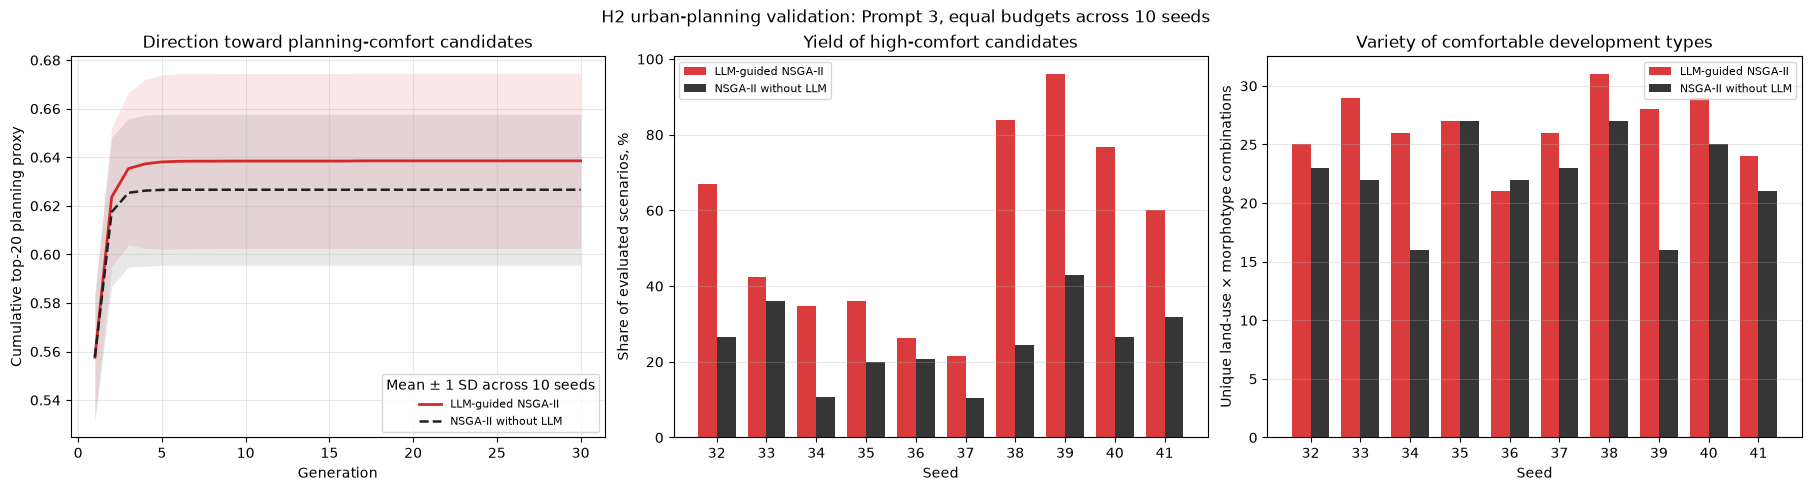

H2 planning decision: SUPPORTED


In [20]:
from scipy.stats import binomtest

H2_PLANNING_PROMPT = 3
H2_PLANNING_SEEDS = range(32, 42)
H2_PLANNING_POPULATION = 20
H2_PLANNING_GENERATIONS = 30
H2_PLANNING_TOP_K = 20
H2_PLANNING_SHARE_COLUMNS = [
    "residential", "business", "recreation", "industrial",
    "transport", "special", "agriculture",
]


def load_planning_search(seed, algorithm):
    if algorithm == "LLM-guided NSGA-II":
        path = (
            llm_root / f"seed_{seed}" / f"prompt_{H2_PLANNING_PROMPT}"
            / f"prompt_{H2_PLANNING_PROMPT}_optimization_log.jsonl"
        )
    else:
        path = no_llm_root / f"seed_{seed}" / f"no_llm_optimization_log_{seed}.jsonl"
    log = read_jsonl(path).sort_values("eval_id").reset_index(drop=True)
    expected = H2_PLANNING_POPULATION * H2_PLANNING_GENERATIONS
    if len(log) != expected or log["eval_id"].duplicated().any():
        raise ValueError(f"Expected {expected} unique evaluations in {path}, got {len(log)}")
    params = pd.json_normalize(log["params_repaired"].tolist())
    missing = set(H2_PLANNING_SHARE_COLUMNS + ["gsi", "l", "land_use", "morphotype"]) - set(params)
    if missing:
        raise ValueError(f"Missing planning parameters in {path}: {sorted(missing)}")
    shares = params[H2_PLANNING_SHARE_COLUMNS].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    share_sum = shares.sum(axis=1, keepdims=True)
    if np.isnan(shares).any() or np.any(share_sum <= 0):
        raise ValueError(f"Invalid land-use shares in {path}")
    shares = shares / share_sum
    nonzero = np.where(shares > 0, shares, 1.0)
    mix_entropy = -(shares * np.log(nonzero)).sum(axis=1) / np.log(len(H2_PLANNING_SHARE_COLUMNS))
    return pd.DataFrame({
        "seed": seed,
        "algorithm": algorithm,
        "eval_id": pd.to_numeric(log["eval_id"], errors="raise"),
        "functional_mix": mix_entropy,
        "active_use_share": shares[:, 1] + shares[:, 2],
        "gsi": pd.to_numeric(params["gsi"], errors="raise"),
        "floor_count": pd.to_numeric(params["l"], errors="raise"),
        "land_use": params["land_use"].astype(str),
        "morphotype": params["morphotype"].astype(str),
    })


h2_planning_search = pd.concat([
    load_planning_search(seed, algorithm)
    for seed in H2_PLANNING_SEEDS
    for algorithm in ("LLM-guided NSGA-II", "NSGA-II without LLM")
], ignore_index=True)

# Pooled scaling is fixed across both algorithms and all seeds.
for source, target, higher_is_better in [
    ("gsi", "open_ground_potential", False),
    ("floor_count", "human_scale_potential", False),
]:
    minimum = h2_planning_search[source].min()
    value_range = h2_planning_search[source].max() - minimum
    normalized = (h2_planning_search[source] - minimum) / (value_range if value_range else 1.0)
    h2_planning_search[target] = normalized if higher_is_better else 1.0 - normalized

H2_PLANNING_COMPONENTS = [
    "functional_mix", "active_use_share", "open_ground_potential", "human_scale_potential",
]
h2_planning_search["planning_comfort_proxy"] = h2_planning_search[H2_PLANNING_COMPONENTS].mean(axis=1)

baseline_proxy = h2_planning_search.loc[
    h2_planning_search["algorithm"] == "NSGA-II without LLM", "planning_comfort_proxy"
]
H2_HIGH_COMFORT_THRESHOLD = baseline_proxy.quantile(0.75)
h2_planning_search["high_comfort_candidate"] = (
    h2_planning_search["planning_comfort_proxy"] >= H2_HIGH_COMFORT_THRESHOLD
)
h2_planning_search["typology"] = (
    h2_planning_search["land_use"] + " × " + h2_planning_search["morphotype"]
)


def planning_seed_metrics(group):
    comfortable = group[group["high_comfort_candidate"]]
    return pd.Series({
        "mean_planning_proxy": group["planning_comfort_proxy"].mean(),
        "high_comfort_count": len(comfortable),
        "high_comfort_share": group["high_comfort_candidate"].mean(),
        "comfortable_typology_count": comfortable["typology"].nunique(),
        "functional_mix": group["functional_mix"].mean(),
        "active_use_share": group["active_use_share"].mean(),
        "open_ground_potential": group["open_ground_potential"].mean(),
        "human_scale_potential": group["human_scale_potential"].mean(),
    })


h2_planning_seed_results = (
    h2_planning_search.groupby(["seed", "algorithm"], sort=True)
    .apply(planning_seed_metrics, include_groups=False)
    .reset_index()
)
h2_planning_wide = h2_planning_seed_results.pivot(
    index="seed", columns="algorithm",
)

planning_effect_specs = [
    ("mean_planning_proxy", "Mean planning-comfort proxy", True),
    ("high_comfort_count", "High-comfort candidate yield", True),
    ("comfortable_typology_count", "Comfortable typology richness", True),
    ("functional_mix", "Functional-mix entropy", True),
    ("active_use_share", "Active-use share", True),
    ("open_ground_potential", "Unbuilt-ground potential", True),
    ("human_scale_potential", "Human-scale massing potential", True),
]
h2_planning_effect_rows = []
for metric, label, higher_is_better in planning_effect_specs:
    delta = (
        h2_planning_wide[metric]["LLM-guided NSGA-II"]
        - h2_planning_wide[metric]["NSGA-II without LLM"]
    )
    oriented_delta = delta if higher_is_better else -delta
    n_better = int((oriented_delta > 0).sum())
    h2_planning_effect_rows.append({
        "metric": label,
        "median_delta": delta.median(),
        "mean_delta": delta.mean(),
        "llm_better_seeds": n_better,
        "n_seeds": len(delta),
        "sign_test_p_one_sided": binomtest(
            n_better, len(delta), p=0.5, alternative="greater"
        ).pvalue,
    })

h2_planning_effects = pd.DataFrame(h2_planning_effect_rows)
display(pd.DataFrame({
    "high_comfort_threshold": [H2_HIGH_COMFORT_THRESHOLD],
    "threshold_definition": ["75th percentile of pooled no-LLM proxy"],
}))
display(h2_planning_effects.style.format({
    "median_delta": "{:+.4f}",
    "mean_delta": "{:+.4f}",
    "sign_test_p_one_sided": "{:.4f}",
}))

# Cumulative top-k trajectory: quality of the best robust option set found so far.
h2_planning_trajectory_rows = []
for (seed, algorithm), group in h2_planning_search.groupby(["seed", "algorithm"]):
    ordered = group.sort_values("eval_id")
    for generation in range(1, H2_PLANNING_GENERATIONS + 1):
        observed = ordered.iloc[:generation * H2_PLANNING_POPULATION]
        top_k = min(H2_PLANNING_TOP_K, len(observed))
        h2_planning_trajectory_rows.append({
            "seed": seed,
            "algorithm": algorithm,
            "generation": generation,
            "top_k_planning_proxy": observed["planning_comfort_proxy"].nlargest(top_k).mean(),
        })
h2_planning_trajectory = pd.DataFrame(h2_planning_trajectory_rows)
h2_planning_trajectory_summary = (
    h2_planning_trajectory.groupby(["algorithm", "generation"])["top_k_planning_proxy"]
    .agg(mean="mean", std="std")
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
planning_styles = {
    "LLM-guided NSGA-II": {"color": "#d62728", "linestyle": "-", "linewidth": 2.0},
    "NSGA-II without LLM": {"color": "#202020", "linestyle": "--", "linewidth": 1.8},
}
for algorithm, style in planning_styles.items():
    stats = h2_planning_trajectory_summary[
        h2_planning_trajectory_summary["algorithm"] == algorithm
    ]
    generation = stats["generation"].to_numpy()
    mean = stats["mean"].to_numpy()
    std = stats["std"].to_numpy()
    axes[0].plot(generation, mean, label=algorithm, **style)
    axes[0].fill_between(
        generation, mean - std, mean + std,
        color=style["color"], alpha=0.10, linewidth=0,
    )
axes[0].set(
    title="Direction toward planning-comfort candidates",
    xlabel="Generation", ylabel="Cumulative top-20 planning proxy",
)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, title="Mean ± 1 SD across 10 seeds")

seed_order = list(H2_PLANNING_SEEDS)
x_seed = np.arange(len(seed_order))
width = 0.38
for offset, algorithm in [(-width / 2, "LLM-guided NSGA-II"), (width / 2, "NSGA-II without LLM")]:
    values = (
        h2_planning_seed_results[h2_planning_seed_results["algorithm"] == algorithm]
        .set_index("seed").loc[seed_order, "high_comfort_share"] * 100
    )
    axes[1].bar(
        x_seed + offset, values, width,
        color=planning_styles[algorithm]["color"],
        alpha=0.90, label=algorithm,
    )
axes[1].set_xticks(x_seed, seed_order)
axes[1].set(
    title="Yield of high-comfort candidates",
    xlabel="Seed", ylabel="Share of evaluated scenarios, %",
)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(fontsize=8)

for offset, algorithm in [(-width / 2, "LLM-guided NSGA-II"), (width / 2, "NSGA-II without LLM")]:
    values = (
        h2_planning_seed_results[h2_planning_seed_results["algorithm"] == algorithm]
        .set_index("seed").loc[seed_order, "comfortable_typology_count"]
    )
    axes[2].bar(
        x_seed + offset, values, width,
        color=planning_styles[algorithm]["color"],
        alpha=0.90, label=algorithm,
    )
axes[2].set_xticks(x_seed, seed_order)
axes[2].set(
    title="Variety of comfortable development types",
    xlabel="Seed", ylabel="Unique land-use × morphotype combinations",
)
axes[2].grid(axis="y", alpha=0.3)
axes[2].legend(fontsize=8)
fig.suptitle("H2 urban-planning validation: Prompt 3, equal budgets across 10 seeds")
plt.show()

primary_metrics = h2_planning_effects.set_index("metric")
h2_planning_supported = all(
    primary_metrics.loc[metric, "llm_better_seeds"] >= 8
    and primary_metrics.loc[metric, "sign_test_p_one_sided"] < 0.05
    for metric in ["Mean planning-comfort proxy", "High-comfort candidate yield"]
)
print(f"H2 planning decision: {'SUPPORTED' if h2_planning_supported else 'NOT SUPPORTED'}")
